In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Classroom',
 'mxz-wmas-bsw - Aug 7, 2021.pdf',
 'Experiment 3 and 4.docx',
 'Untitled document.gdoc',
 'Document from Anubhab Pal (2).pdf',
 'Document from Anubhab Pal (1).pdf',
 'payment_screenshot.jpeg',
 'Document from Anubhab Pal.pdf',
 'Chapter 2: Nutrition in Animals - Visual Edition.gdoc',
 'ch2.pptx',
 'investing in st market unit 1 (1).pptx',
 'Additional information (1).pptx',
 'SAMP Module 1 Part 3 (1).pptx',
 'SAMP Module 1 Part 2-1 (1).pptx',
 'SAMP Module 1 Part 4 (1).pptx',
 'Additional information.pptx',
 'investing in st market unit 1.pptx',
 'SAMP Module 1 Part 2-1.pptx',
 'SAMP Module 1 Part 3.pptx',
 'SAMP Module 1 Part 4.pptx']

In [7]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower() == 'flight_pricing_dataset.csv':
            print(os.path.join(root, file))

In [9]:
import pandas as pd

In [11]:
df = pd.read_csv('/content/drive/MyDrive/Copy of flight_pricing_dataset.csv')

In [12]:
df.shape
df.head()
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Flight_ID              100000 non-null  object
 1   Airline                95120 non-null   object
 2   Source                 95085 non-null   object
 3   Destination            95119 non-null   object
 4   Departure_Date         95073 non-null   object
 5   Departure_Time         95132 non-null   object
 6   Arrival_Time           95211 non-null   object
 7   Duration               94958 non-null   object
 8   Total_Stops            95095 non-null   object
 9   Distance_km            95077 non-null   object
 10  Travel_Class           95137 non-null   object
 11  Days_Before_Departure  95216 non-null   object
 12  Season                 95224 non-null   object
 13  Weekday                95280 non-null   object
 14  Aircraft_Type          95148 non-null   object
 15  B

,0
Flight_ID,0
Airline,4880
Source,4915
Destination,4881
Departure_Date,4927
Departure_Time,4868
Arrival_Time,4789
Duration,5042
Total_Stops,4905
Distance_km,4923


In [13]:
for col in df.columns:
    print("\n" + "="*60)
    print(col)
    print(df[col].dropna().sample(5, random_state=42).tolist())


Flight_ID
['FL182021', 'FL175377', 'FL121873', 'FL107871', 'FL194317']

Airline
['Etihad Airways', 'Indigo', 'Qatar Airways', 'Thai Airways', 'THAI AIRWAYS']

Source
['London Airport', 'Mumbai Airport', 'New York', 'Chennai', 'Sydney']

Destination
['Doha', 'New York', 'JAI', 'DXB', 'Bangkok']

Departure_Date
['2025-01-25', '2025-11-05', '2026-08-11', '2025-03-25', '2026-05-17']

Departure_Time
['02:25', '11:15 AM', '12:25', '1:50 PM', '06:25']

Arrival_Time
['18:20', '00:27', '15:20', '12:27', '1:23 AM']

Duration
['4.33', '17.54', '14h 10m', '609 min', '3h 26m']

Total_Stops
['0', '1', '2', '1', '1']

Distance_km
['846.5', '2865.5', '359.5', '10827.5', '2146.8']

Travel_Class
['Economy', 'Economy', 'Economy', 'Economy', 'Economy']

Days_Before_Departure
['5', '7', '6', '40', '69']

Season
['Autumn', 'Summer', 'Autumn', 'Winter', 'Summer']

Weekday
['Wednesday', 'Sunday', 'Wednesday', 'Wednesday', 'Sunday']

Aircraft_Type
['Boeing 777', 'Boeing 777', 'Boeing 787 Dreamliner', 'Airbus 

In [14]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing.sort_values('Missing_Percentage', ascending=False)

,Missing_Count,Missing_Percentage
Price,5053,5.053
Duration,5042,5.042
Booking_Channel,4962,4.962
Departure_Date,4927,4.927
Distance_km,4923,4.923
Source,4915,4.915
Total_Stops,4905,4.905
Destination,4881,4.881
Airline,4880,4.880
Departure_Time,4868,4.868


In [15]:
categorical_columns = [
    'Airline',
    'Source',
    'Destination',
    'Total_Stops',
    'Travel_Class',
    'Season',
    'Weekday',
    'Aircraft_Type',
    'Booking_Channel'
]

for col in categorical_columns:
    print("\n" + "="*50)
    print(col)
    print(df[col].value_counts(dropna=False).head(20))


Airline
Airline
Singapore Airlines    7864
Etihad Airways        7802
Lufthansa             7786
Emirates              7722
Thai Airways          7708
Qatar Airways         7667
British Airways       7598
Vistara               5649
Air India             4895
NaN                   4880
Indigo                4677
AirAsia India         4649
GoFirst               4630
SpiceJet              4602
air india              740
AIR INDIA              713
thai airways           564
SINGAPORE AIRLINES     546
BRITISH AIRWAYS        536
lufthansa              527
Name: count, dtype: int64

Source
Source
NaN          4915
Chennai      3519
Pune         3506
New York     3502
Singapore    3489
Doha         3482
Bangkok      3480
Hyderabad    3473
Dubai        3467
Ahmedabad    3466
Bangalore    3452
Frankfurt    3451
Mumbai       3434
Jaipur       3433
Sydney       3426
London       3411
Kolkata      3375
Delhi        3353
Goa          3351
GOI           993
Name: count, dtype: int64

Destination
Des

In [16]:
for col in ['Distance_km', 'Days_Before_Departure', 'Passenger_Count', 'Price']:
    print("\n" + "="*50)
    print(col)
    print(df[col].dropna().head(15).tolist())


Distance_km
['910.5', '150', '10168.1', '868.3', '10478.0', '748.9', '2574.9', '12133.2', '2215.6', '1904.9', '3179.9', '376.4', '15583.5', '1189.7', '1624.9']

Days_Before_Departure
['43', '45', '3', '33', '6', '0', '3', '5', '9', '110', '27', '120', '162', '2', '11']

Passenger_Count
['5', '3', '3', '1', '2', '2', '2', '1', '1', '1', '1', '2', '2', '1', '1']

Price
['5181.56', '2000', '174762.69', '2846.09', '145331.64', '190059.64', '6458.88', '28599.41', '147645.15', '24660.74', '36225.75', '15000', '200000', '20785.21', '32822.58']


In [17]:
print(df['Duration'].dropna().sample(30, random_state=42).tolist())

['4.33', '17.54', '14h 10m', '609 min', '3h 26m', '10h 34m', '19h 23m', '9h 50m', '6h 29m', '4h 08m', '16h 56m', '8.68', '6h 49m', '10.64', '10h 41m', '16.94', '9h 46m', '6h 39m', '10h 38m', '3h 41m', '1h 47m', '10h 22m', '23h 26m', '707 min', '1h 31m', '4h 18m', '12h 08m', '8.87', '1h 11m', '3h 40m']


In [19]:
print(df['Duration'].dropna().astype(str).str.contains('h').sum())
print(df['Duration'].dropna().astype(str).str.contains('min').sum())
print(df['Duration'].dropna().str.match(r'^\d+(\.\d+)?$').sum())

69962
12428
12568


In [20]:
categorical_columns = [
    'Airline',
    'Source',
    'Destination',
    'Total_Stops',
    'Travel_Class',
    'Season',
    'Weekday',
    'Aircraft_Type',
    'Booking_Channel'
]

for col in categorical_columns:
    print("\n" + "="*50)
    print(col)
    print(df[col].value_counts(dropna=False).head(20))


Airline
Airline
Singapore Airlines    7864
Etihad Airways        7802
Lufthansa             7786
Emirates              7722
Thai Airways          7708
Qatar Airways         7667
British Airways       7598
Vistara               5649
Air India             4895
NaN                   4880
Indigo                4677
AirAsia India         4649
GoFirst               4630
SpiceJet              4602
air india              740
AIR INDIA              713
thai airways           564
SINGAPORE AIRLINES     546
BRITISH AIRWAYS        536
lufthansa              527
Name: count, dtype: int64

Source
Source
NaN          4915
Chennai      3519
Pune         3506
New York     3502
Singapore    3489
Doha         3482
Bangkok      3480
Hyderabad    3473
Dubai        3467
Ahmedabad    3466
Bangalore    3452
Frankfurt    3451
Mumbai       3434
Jaipur       3433
Sydney       3426
London       3411
Kolkata      3375
Delhi        3353
Goa          3351
GOI           993
Name: count, dtype: int64

Destination
Des

In [21]:
numeric_columns = [
    'Distance_km',
    'Days_Before_Departure',
    'Passenger_Count',
    'Price'
]

for col in numeric_columns:
    print("\n" + "="*50)
    print(col)
    print("Unique values:", df[col].nunique())
    print("Examples:", df[col].dropna().sample(10, random_state=42).tolist())


Distance_km
Unique values: 59484
Examples: ['846.5', '2865.5', '359.5', '10827.5', '2146.8', '12775.9', '4153.0', '760.2', '6998.4', '1715.7']

Days_Before_Departure
Unique values: 341
Examples: ['5', '7', '6', '40', '69', '20', '143', '38', '37', '5']

Passenger_Count
Unique values: 12
Examples: ['1', '1', '2', '5', 'one', '1', '1', '5', '3', '6']

Price
Unique values: 78725
Examples: ['3223.64', '133769.57', '132415.7', '5203.7', '88190.81', '91180.91', '97323.49', '111243.39', '9533.94', '110490.97']


In [23]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Flight IDs:", df['Flight_ID'].duplicated().sum())

Duplicate rows: 1961
Duplicate Flight IDs: 1961


In [24]:
print(df[df['Duration'].astype(str).str.match(r'^\d+(\.\d+)?$')][
    ['Duration', 'Distance_km', 'Total_Stops', 'Price']
].sample(20, random_state=42).to_string(index=False))

Duration Distance_km Total_Stops     Price
   12.80      7759.7           2 100454.99
    3.80      2577.3           0   20035.2
    2.20      1325.2           0    8837.0
   15.86     10618.0           1  89250.45
   11.77      7858.2         NaN  86818.29
    1.97      1143.6    non-stop  12020.83
    5.42      2961.2           1  24255.22
    2.81      1800.6           0       NaN
   12.11      7868.9      1 stop  81301.46
    3.31       909.2           1       NaN
   11.10      8266.5           0  70949.67
   12.12      8105.9           1 113362.97
    2.21      1333.7           0   8932.18
    2.01      1181.7           0  10651.16
   10.58      5178.2           2  75507.61
    3.68      1366.2           1   5606.96
    2.25       370.5           1   2097.81
   17.82     11039.7     2 stops  96659.36
    6.43      3479.7           1  43629.25
   16.17     10885.1      1 stop  81032.87


In [25]:
print(df['Total_Stops'].value_counts(dropna=False))

Total_Stops
1           26710
0           22887
1 stop      17673
non-stop    15433
2            7358
2 stops      5034
NaN          4905
Name: count, dtype: int64


In [26]:
for col in [
    'Source',
    'Destination',
    'Total_Stops',
    'Travel_Class',
    'Season',
    'Weekday',
    'Aircraft_Type',
    'Booking_Channel'
]:
    print("\n" + "="*50)
    print(col)
    print(df[col].value_counts(dropna=False).to_string())


Source
Source
NaN                  4915
Chennai              3519
Pune                 3506
New York             3502
Singapore            3489
Doha                 3482
Bangkok              3480
Hyderabad            3473
Dubai                3467
Ahmedabad            3466
Bangalore            3452
Frankfurt            3451
Mumbai               3434
Jaipur               3433
Sydney               3426
London               3411
Kolkata              3375
Delhi                3353
Goa                  3351
GOI                   993
Jaipur Airport        965
Ahmedabad Airport     957
DEL                   954
BKK                   952
BOM                   943
BLR                   942
DXB                   941
LHR                   936
Kolkata Airport       933
Dubai Airport         928
MAA                   926
HYD                   926
Mumbai Airport        925
JFK                   925
SIN                   923
New York Airport      919
Delhi Airport         919
Hyderabad Airport     9

In [27]:
clean_df = df.copy()

In [28]:
before = len(clean_df)

clean_df = clean_df.drop_duplicates()

after = len(clean_df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 100000
Rows after: 98039
Duplicates removed: 1961


In [30]:
clean_df['Airline'] = (
    clean_df['Airline']
    .astype('string')
    .str.strip()
    .str.lower()
)

In [31]:
clean_df['Airline'].value_counts(dropna=False)

,count
Airline,
singapore airlines,8772
lufthansa,8663
etihad airways,8614
thai airways,8576
emirates,8570
qatar airways,8503
british airways,8456
vistara,6287
air india,6198


In [32]:
clean_df['Total_Stops'] = (
    clean_df['Total_Stops']
    .astype('string')
    .str.strip()
    .str.lower()
)

In [33]:
stop_mapping = {
    'non-stop': '0',
    '0': '0',
    '1 stop': '1',
    '1': '1',
    '2 stops': '2',
    '2': '2'
}

clean_df['Total_Stops'] = clean_df['Total_Stops'].replace(stop_mapping)

In [34]:
clean_df['Total_Stops'] = pd.to_numeric(
    clean_df['Total_Stops'],
    errors='coerce'
)

In [35]:
clean_df['Total_Stops'].value_counts(dropna=False)

,count
Total_Stops,
1,43463
0,37599
2,12156
<NA>,4821


In [36]:
clean_df['Passenger_Count'] = (
    clean_df['Passenger_Count']
    .astype('string')
    .str.strip()
    .str.lower()
)

clean_df['Passenger_Count'] = clean_df['Passenger_Count'].replace({
    'one': '1',
    'two': '2',
    'three': '3',
    'four': '4',
    'five': '5',
    'six': '6',
    'seven': '7',
    'eight': '8',
    'nine': '9',
    'ten': '10'
})

clean_df['Passenger_Count'] = pd.to_numeric(
    clean_df['Passenger_Count'],
    errors='coerce'
)

In [37]:
clean_df['Passenger_Count'].value_counts(dropna=False).sort_index()

,count
Passenger_Count,
1,39147
2,27597
3,12285
4,7584
5,3886
6,2807
<NA>,4733


In [39]:
numeric_columns = [
    'Distance_km',
    'Days_Before_Departure',
    'Passenger_Count',
    'Price'
]

for col in numeric_columns:
    clean_df[col] = pd.to_numeric(
        clean_df[col],
        errors='coerce'
    )

In [40]:
clean_df[numeric_columns].dtypes

,0
Distance_km,float64
Days_Before_Departure,float64
Passenger_Count,Int64
Price,float64


In [41]:
def duration_to_minutes(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Format: "14h 10m", "3h 26m", etc.
    if 'h' in value:
        parts = value.split('h')

        hours = float(parts[0].strip())

        minutes = 0

        if len(parts) > 1:
            minute_part = parts[1].replace('m', '').strip()

            if minute_part:
                minutes = float(minute_part)

        return hours * 60 + minutes

    # Format: "609 min"
    elif 'min' in value:
        return float(value.replace('min', '').strip())

    # Decimal format such as "4.33"
    else:
        return float(value) * 60

In [43]:
import numpy as np

In [44]:
clean_df['Duration_Minutes'] = clean_df['Duration'].apply(
    duration_to_minutes
)

In [45]:
clean_df[['Duration', 'Duration_Minutes']].sample(
    20,
    random_state=42
)

,Duration,Duration_Minutes
7434,6.03,361.8
38447,3.59,215.4
35746,15h 13m,913.0
21790,2h 17m,137.0
40679,17h 53m,1073.0
91824,3h 35m,215.0
58842,307 min,307.0
21138,81 min,81.0
99954,11h 29m,689.0
92621,6.99,419.4


In [46]:
clean_df['Departure_Date'] = pd.to_datetime(
    clean_df['Departure_Date'],
    errors='coerce'
)

In [47]:
clean_df['Departure_Year'] = clean_df['Departure_Date'].dt.year
clean_df['Departure_Month'] = clean_df['Departure_Date'].dt.month
clean_df['Departure_Day'] = clean_df['Departure_Date'].dt.day

In [48]:
clean_df.info()
clean_df.shape
clean_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 98039 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Flight_ID              98039 non-null  object        
 1   Airline                93251 non-null  string        
 2   Source                 93224 non-null  object        
 3   Destination            93255 non-null  object        
 4   Departure_Date         93197 non-null  datetime64[ns]
 5   Departure_Time         93266 non-null  object        
 6   Arrival_Time           93338 non-null  object        
 7   Duration               93099 non-null  object        
 8   Total_Stops            93218 non-null  Int64         
 9   Distance_km            90444 non-null  float64       
 10  Travel_Class           93276 non-null  object        
 11  Days_Before_Departure  91972 non-null  float64       
 12  Season                 93350 non-null  object        
 13  Weekda

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,...,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price,Duration_Minutes,Departure_Year,Departure_Month,Departure_Day
0,FL133547,indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,1.67,0,910.5,...,Monsoon,Saturday,Boeing 737,Mobile App,5,5181.56,100.2,2025.0,8.0,2.0
1,FL133458,airasia india,Pune,Mumbai,2025-06-05,12:10,12:55,0h 45m,0,150.0,...,Monsoon,Thursday,ATR 72,Website,3,2000.00,45.0,2025.0,6.0,5.0
2,FL173851,qatar airways,Sydney,PNQ,2025-02-11,5:05 PM,7:53 AM,14.80,1,10168.1,...,NaN,Tuesday,Boeing 777,Mobile App,3,174762.69,888.0,2025.0,2.0,11.0
3,FL101953,airasia india,Bangalore Airport,BOM,2025-04-19,07:05,10:16 AM,3h 11m,1,868.3,...,Summer,Saturday,Airbus A320,Mobile App,1,2846.09,191.0,2025.0,4.0,19.0
4,FL162887,british airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,13.93,0,10478.0,...,Monsoon,Sunday,Airbus A320,Website,2,145331.64,835.8,2026.0,7.0,5.0


In [49]:
missing = pd.DataFrame({
    'Missing_Count': clean_df.isnull().sum(),
    'Missing_Percentage': (clean_df.isnull().sum() / len(clean_df)) * 100
})

missing = missing.sort_values(
    'Missing_Percentage',
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
Price,7781,7.936637
Distance_km,7595,7.746917
Days_Before_Departure,6067,6.188354
Duration,4940,5.038811
Duration_Minutes,4940,5.038811
Booking_Channel,4871,4.968431
Departure_Day,4842,4.938851
Departure_Date,4842,4.938851
Departure_Year,4842,4.938851
Departure_Month,4842,4.938851


In [50]:
clean_df[
    [
        'Distance_km',
        'Days_Before_Departure',
        'Passenger_Count',
        'Price',
        'Duration_Minutes'
    ]
].describe()

,Distance_km,Days_Before_Departure,Passenger_Count,Price,Duration_Minutes
count,90444.000000,91972.000000,93306.0,90258.000000,93099.000000
mean,5153.335414,35.836766,2.119949,73026.488942,488.028709
std,4423.836084,43.800426,1.31078,77758.536856,358.837067
min,150.000000,0.000000,1.0,152.130000,45.000000
25%,1536.700000,7.000000,1.0,13317.805000,198.000000
50%,3213.500000,19.000000,2.0,49159.030000,354.000000
75%,7901.000000,41.000000,3.0,113713.815000,731.000000
max,18353.400000,180.000000,6.0,999306.030000,1647.000000


In [51]:
clean_df[
    ['Duration', 'Duration_Minutes']
].sample(20, random_state=42)

,Duration,Duration_Minutes
7434,6.03,361.8
38447,3.59,215.4
35746,15h 13m,913.0
21790,2h 17m,137.0
40679,17h 53m,1073.0
91824,3h 35m,215.0
58842,307 min,307.0
21138,81 min,81.0
99954,11h 29m,689.0
92621,6.99,419.4


In [52]:
for col in [
    'Airline',
    'Source',
    'Destination',
    'Total_Stops',
    'Travel_Class',
    'Season',
    'Weekday',
    'Aircraft_Type',
    'Booking_Channel'
]:
    print("\n" + "="*50)
    print(col)
    print(clean_df[col].value_counts(dropna=False).head(15))


Airline
Airline
singapore airlines    8772
lufthansa             8663
etihad airways        8614
thai airways          8576
emirates              8570
qatar airways         8503
british airways       8456
vistara               6287
air india             6198
airasia india         5182
indigo                5176
gofirst               5142
spicejet              5112
<NA>                  4788
Name: count, dtype: Int64

Source
Source
NaN          4815
Chennai      3456
Pune         3431
Doha         3427
Singapore    3426
New York     3412
Hyderabad    3406
Bangkok      3405
Dubai        3396
Frankfurt    3393
Ahmedabad    3391
Bangalore    3382
Jaipur       3370
Mumbai       3364
Sydney       3363
Name: count, dtype: int64

Destination
Destination
NaN          4784
Bangkok      3427
Goa          3426
Hyderabad    3420
Pune         3413
Ahmedabad    3411
London       3377
Doha         3366
Delhi        3364
Bangalore    3354
Mumbai       3350
Chennai      3347
Kolkata      3333
Singapore

In [53]:
clean_df = clean_df.drop(columns=['Duration'])

In [54]:
clean_df['Departure_Hour'] = pd.to_datetime(
    clean_df['Departure_Time'],
    format='mixed',
    errors='coerce'
).dt.hour

In [55]:
clean_df[['Departure_Time', 'Departure_Hour']].sample(
    15,
    random_state=42
)

,Departure_Time,Departure_Hour
7434,7:00 AM,7.0
38447,6:40 AM,6.0
35746,1:40 PM,13.0
21790,08:35,8.0
40679,11:40,11.0
91824,01:10,1.0
58842,22:45,22.0
21138,23:10,23.0
99954,8:20 PM,20.0
92621,05:00,5.0


In [56]:
clean_df['Arrival_Hour'] = pd.to_datetime(
    clean_df['Arrival_Time'],
    format='mixed',
    errors='coerce'
).dt.hour

In [57]:
clean_df[['Arrival_Time', 'Arrival_Hour']].sample(
    15,
    random_state=42
)

,Arrival_Time,Arrival_Hour
7434,13:01,13.0
38447,10:15 AM,10.0
35746,04:52,4.0
21790,10:52 AM,10.0
40679,5:33 AM,5.0
91824,4:45 AM,4.0
58842,03:52,3.0
21138,12:30 AM,0.0
99954,07:48,7.0
92621,11:59 AM,11.0


In [58]:
def get_time_period(hour):
    if pd.isna(hour):
        return np.nan
    elif hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

clean_df['Departure_Period'] = clean_df['Departure_Hour'].apply(
    get_time_period
)

In [59]:
clean_df['Departure_Period'].value_counts(dropna=False)

,count
Departure_Period,
Afternoon,23343
Evening,23331
Night,23321
Morning,23271
NaN,4773


In [60]:
clean_df.shape
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98039 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Flight_ID              98039 non-null  object        
 1   Airline                93251 non-null  string        
 2   Source                 93224 non-null  object        
 3   Destination            93255 non-null  object        
 4   Departure_Date         93197 non-null  datetime64[ns]
 5   Departure_Time         93266 non-null  object        
 6   Arrival_Time           93338 non-null  object        
 7   Total_Stops            93218 non-null  Int64         
 8   Distance_km            90444 non-null  float64       
 9   Travel_Class           93276 non-null  object        
 10  Days_Before_Departure  91972 non-null  float64       
 11  Season                 93350 non-null  object        
 12  Weekday                93420 non-null  object        
 13  Aircra

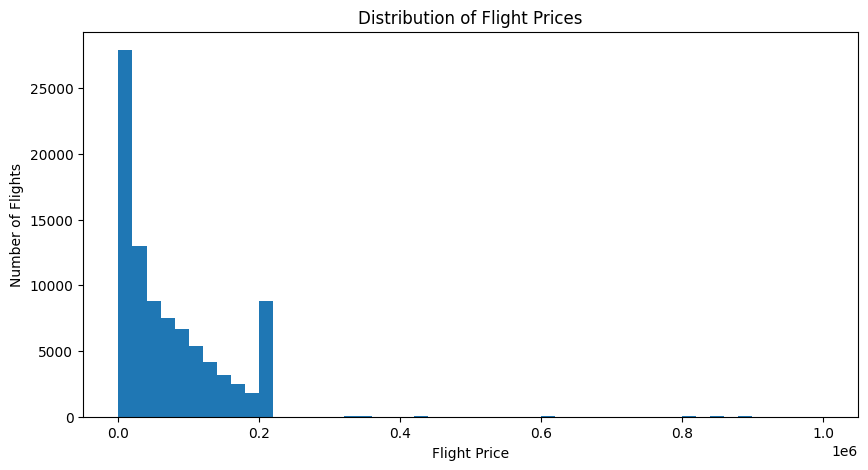

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    clean_df['Price'].dropna(),
    bins=50
)

plt.xlabel('Flight Price')
plt.ylabel('Number of Flights')
plt.title('Distribution of Flight Prices')

plt.show()

In [62]:
clean_df.groupby('Travel_Class')['Price'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('median', ascending=False)

,count,mean,median,min,max
Travel_Class,,,,,
First,3550,134060.754085,184200.855,179.07,951680.10
Business,10191,115806.916136,116471.230,192.96,964247.38
Premium Economy,13574,81949.196527,61339.040,161.86,994384.70
Economy,58552,59666.916583,39824.330,152.13,999306.03


In [63]:
clean_df.groupby('Airline')['Price'].agg(
    ['count', 'mean', 'median']
).sort_values('median', ascending=False)

,count,mean,median
Airline,,,
qatar airways,7864,101218.814695,86060.265
etihad airways,7952,100368.639326,85175.985
emirates,7948,99962.419490,85115.960
singapore airlines,8032,100557.631600,84814.605
thai airways,7916,99579.491549,84802.265
british airways,7761,99815.269909,84100.920
lufthansa,7952,98799.870113,83152.245
vistara,5792,45149.312103,16949.640
air india,5722,45521.445734,16470.875


<Figure size 1000x600 with 0 Axes>

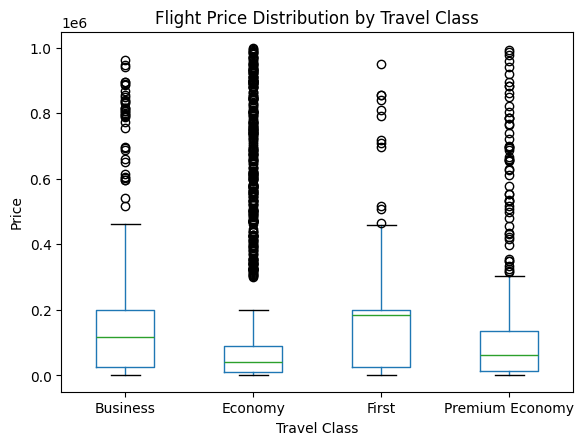

In [64]:
plt.figure(figsize=(10, 6))

clean_df.boxplot(
    column='Price',
    by='Travel_Class',
    grid=False
)

plt.title('Flight Price Distribution by Travel Class')
plt.suptitle('')
plt.xlabel('Travel Class')
plt.ylabel('Price')

plt.show()

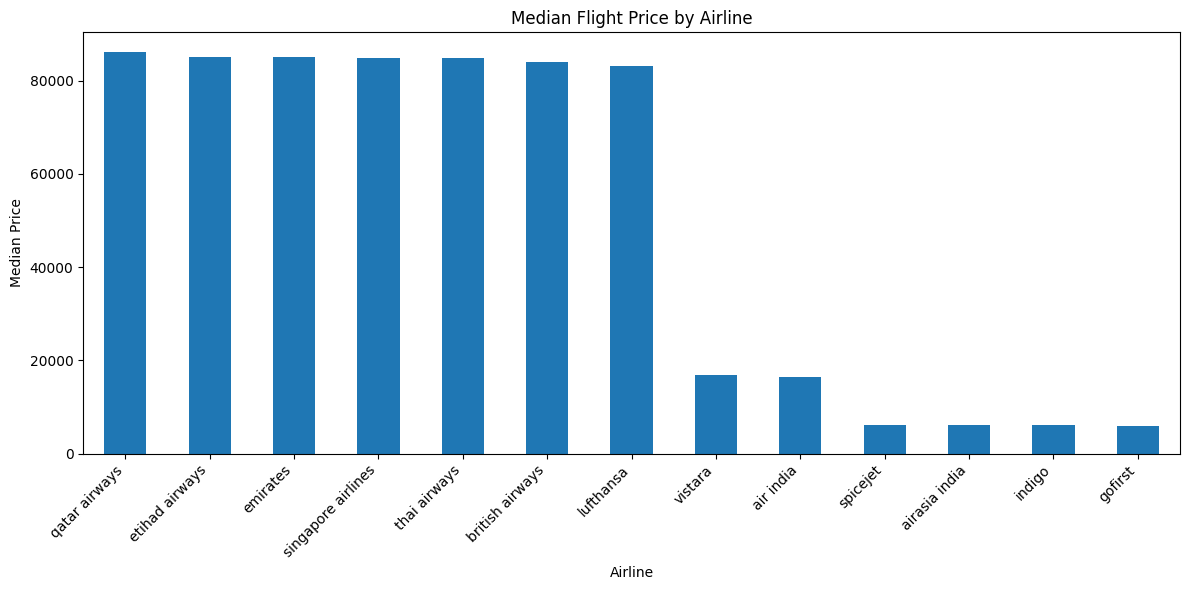

In [65]:
airline_median = (
    clean_df.groupby('Airline')['Price']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

airline_median.plot(kind='bar')

plt.title('Median Flight Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Median Price')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

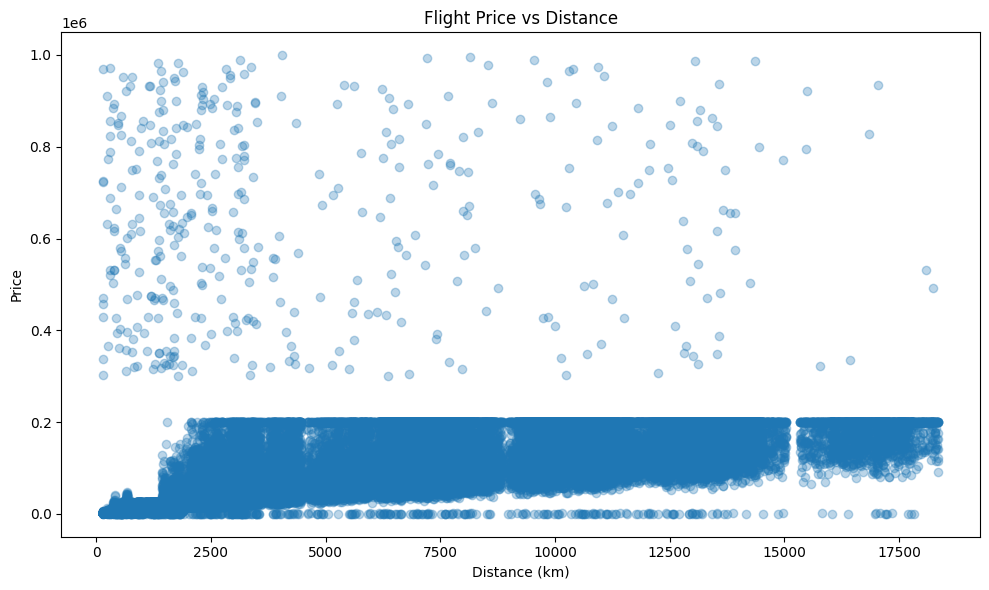

In [66]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['Distance_km'],
    clean_df['Price'],
    alpha=0.3
)

plt.xlabel('Distance (km)')
plt.ylabel('Price')
plt.title('Flight Price vs Distance')

plt.tight_layout()
plt.show()

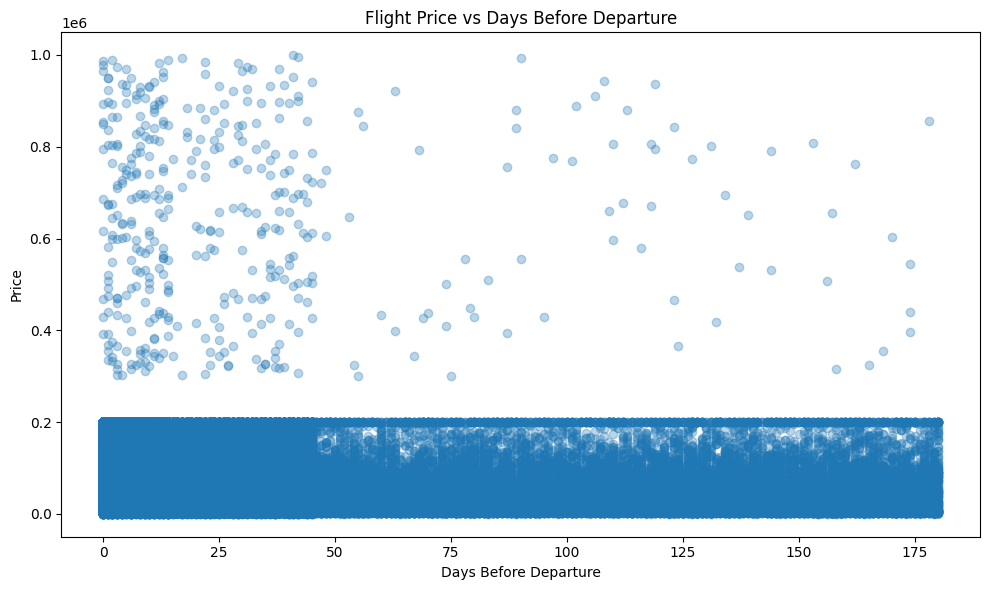

In [67]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['Days_Before_Departure'],
    clean_df['Price'],
    alpha=0.3
)

plt.xlabel('Days Before Departure')
plt.ylabel('Price')
plt.title('Flight Price vs Days Before Departure')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

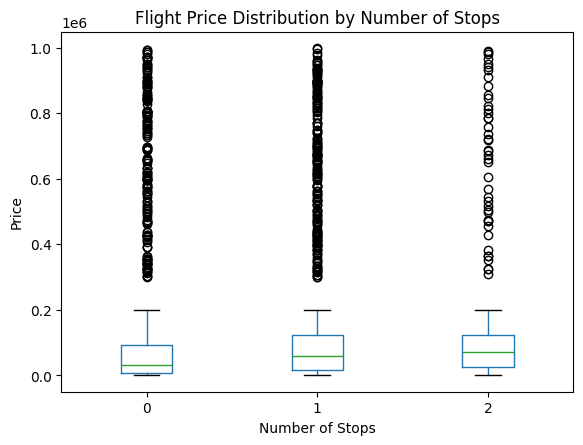

In [68]:
plt.figure(figsize=(10, 6))

clean_df.boxplot(
    column='Price',
    by='Total_Stops',
    grid=False
)

plt.title('Flight Price Distribution by Number of Stops')
plt.suptitle('')
plt.xlabel('Number of Stops')
plt.ylabel('Price')

plt.show()

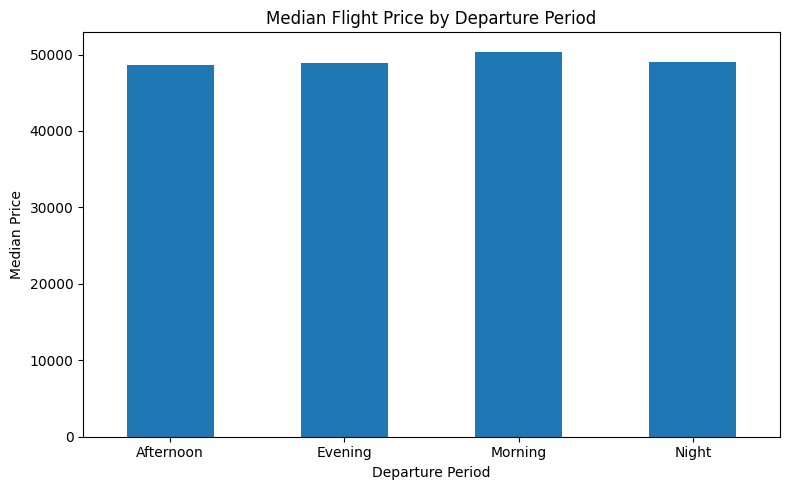

In [69]:
period_median = (
    clean_df.groupby('Departure_Period')['Price']
    .median()
)

plt.figure(figsize=(8, 5))

period_median.plot(kind='bar')

plt.title('Median Flight Price by Departure Period')
plt.xlabel('Departure Period')
plt.ylabel('Median Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

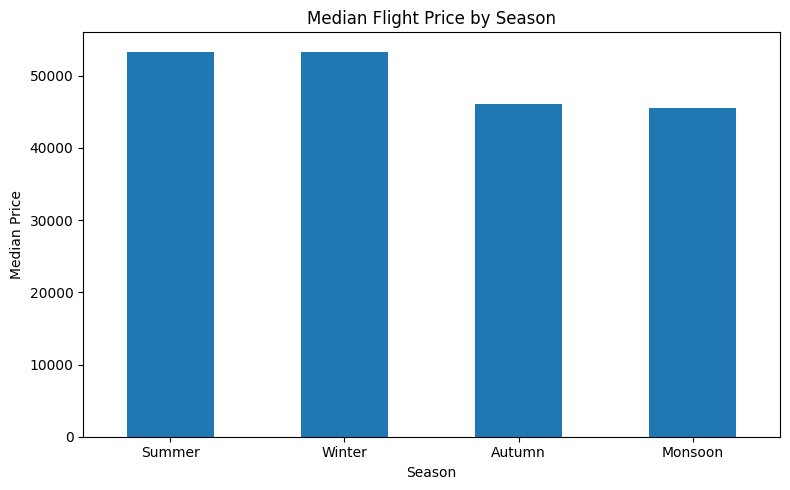

In [70]:
season_median = (
    clean_df.groupby('Season')['Price']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

season_median.plot(kind='bar')

plt.title('Median Flight Price by Season')
plt.xlabel('Season')
plt.ylabel('Median Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

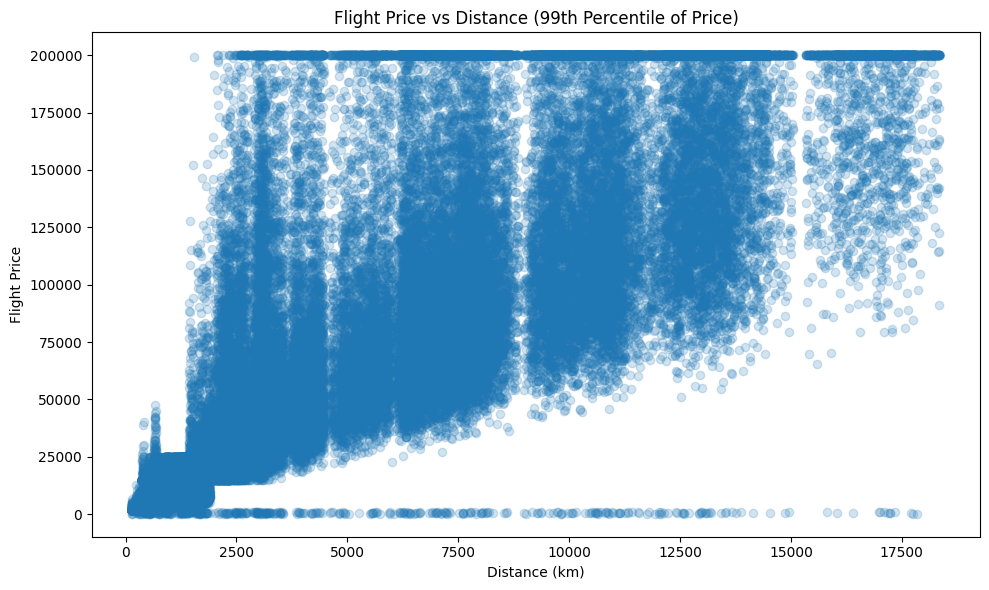

In [71]:
price_99 = clean_df['Price'].quantile(0.99)

plot_df = clean_df[
    clean_df['Price'].notna() &
    clean_df['Distance_km'].notna() &
    (clean_df['Price'] <= price_99)
]

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df['Distance_km'],
    plot_df['Price'],
    alpha=0.2
)

plt.xlabel('Distance (km)')
plt.ylabel('Flight Price')
plt.title('Flight Price vs Distance (99th Percentile of Price)')

plt.tight_layout()
plt.show()

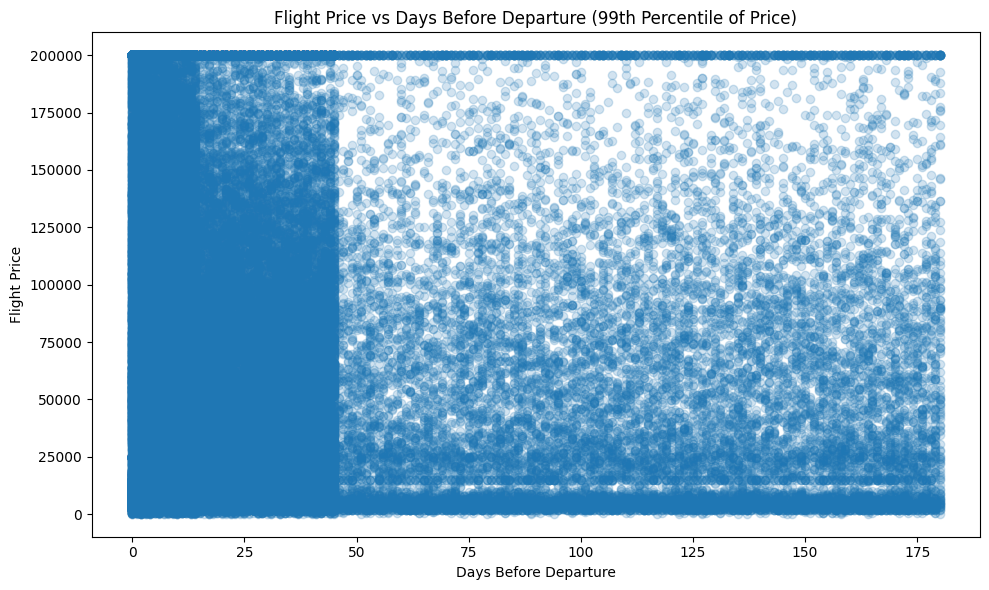

In [72]:
price_99 = clean_df['Price'].quantile(0.99)

plot_df = clean_df[
    clean_df['Price'].notna() &
    clean_df['Days_Before_Departure'].notna() &
    (clean_df['Price'] <= price_99)
]

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df['Days_Before_Departure'],
    plot_df['Price'],
    alpha=0.2
)

plt.xlabel('Days Before Departure')
plt.ylabel('Flight Price')
plt.title('Flight Price vs Days Before Departure (99th Percentile of Price)')

plt.tight_layout()
plt.show()

In [73]:
def booking_window(days):
    if pd.isna(days):
        return np.nan
    elif days <= 7:
        return '0–7 days'
    elif days <= 30:
        return '8–30 days'
    elif days <= 60:
        return '31–60 days'
    elif days <= 90:
        return '61–90 days'
    else:
        return '91+ days'

clean_df['Booking_Window'] = clean_df[
    'Days_Before_Departure'
].apply(booking_window)

In [74]:
clean_df.groupby('Booking_Window')['Price'].agg(
    ['count', 'median', 'mean']
).sort_values('median')

,count,median,mean
Booking_Window,,,
91+ days,11171,39106.030,60592.549159
31–60 days,16284,39133.925,62572.236364
61–90 days,3755,39685.130,62173.631720
8–30 days,31549,48157.910,72204.453372
0–7 days,21916,68093.435,89755.707201


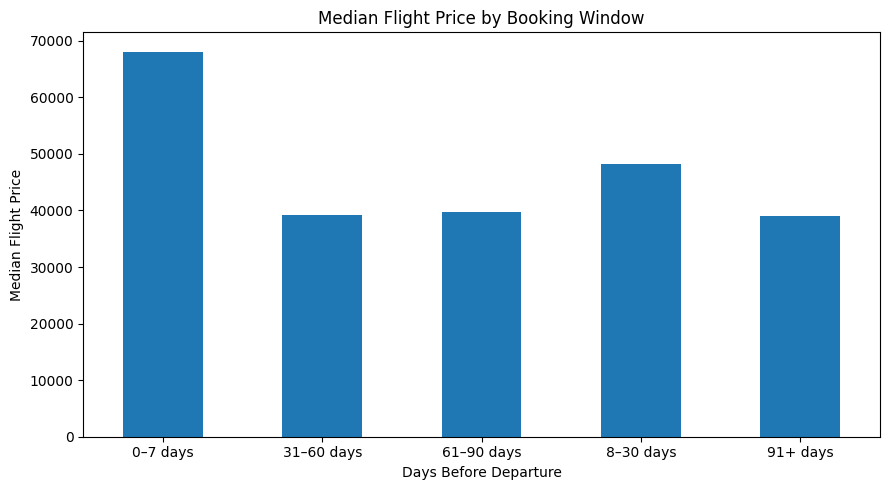

In [75]:
booking_median = (
    clean_df.groupby('Booking_Window')['Price']
    .median()
)

plt.figure(figsize=(9, 5))

booking_median.plot(kind='bar')

plt.title('Median Flight Price by Booking Window')
plt.xlabel('Days Before Departure')
plt.ylabel('Median Flight Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

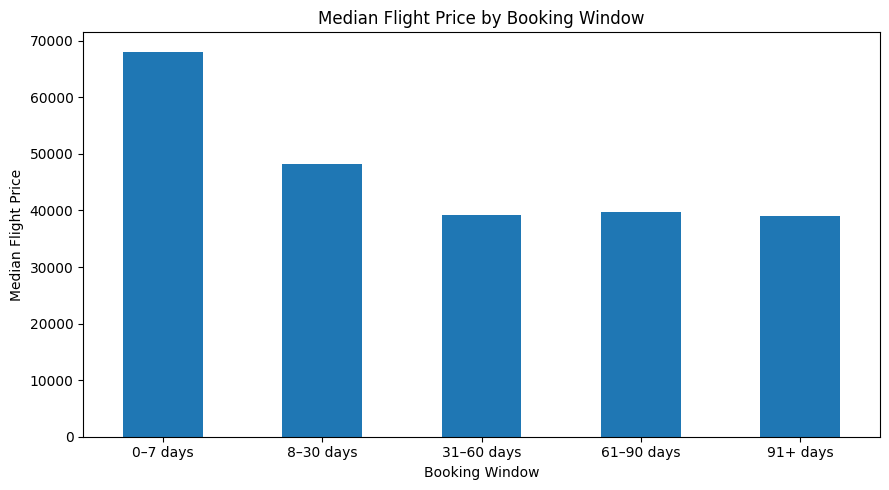

In [76]:
booking_order = [
    '0–7 days',
    '8–30 days',
    '31–60 days',
    '61–90 days',
    '91+ days'
]

booking_median = (
    clean_df.groupby('Booking_Window')['Price']
    .median()
    .reindex(booking_order)
)

plt.figure(figsize=(9, 5))

booking_median.plot(kind='bar')

plt.title('Median Flight Price by Booking Window')
plt.xlabel('Booking Window')
plt.ylabel('Median Flight Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [77]:
features = [
    'Airline',
    'Source',
    'Destination',
    'Departure_Year',
    'Departure_Month',
    'Departure_Day',
    'Departure_Hour',
    'Arrival_Hour',
    'Duration_Minutes',
    'Total_Stops',
    'Distance_km',
    'Travel_Class',
    'Days_Before_Departure',
    'Season',
    'Weekday',
    'Aircraft_Type',
    'Booking_Channel',
    'Passenger_Count',
    'Departure_Period',
    'Booking_Window'
]

target = 'Price'

X = clean_df[features]
y = clean_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature types:")
print(X.dtypes)

X shape: (98039, 20)
y shape: (98039,)

Feature types:
Airline                  string[python]
Source                           object
Destination                      object
Departure_Year                  float64
Departure_Month                 float64
Departure_Day                   float64
Departure_Hour                  float64
Arrival_Hour                    float64
Duration_Minutes                float64
Total_Stops                       Int64
Distance_km                     float64
Travel_Class                     object
Days_Before_Departure           float64
Season                           object
Weekday                          object
Aircraft_Type                    object
Booking_Channel                  object
Passenger_Count                   Int64
Departure_Period                 object
Booking_Window                   object
dtype: object


In [78]:
model_df = clean_df[clean_df['Price'].notna()].copy()

print("Original rows:", len(clean_df))
print("Rows available for modeling:", len(model_df))
print("Rows removed because Price was missing:",
      clean_df['Price'].isna().sum())

Original rows: 98039
Rows available for modeling: 90258
Rows removed because Price was missing: 7781


In [79]:
X = model_df[features]
y = model_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (90258, 20)
y shape: (90258,)


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 72206
Testing samples: 18052


In [81]:
numeric_features = [
    'Departure_Year',
    'Departure_Month',
    'Departure_Day',
    'Departure_Hour',
    'Arrival_Hour',
    'Duration_Minutes',
    'Total_Stops',
    'Distance_km',
    'Days_Before_Departure',
    'Passenger_Count'
]

categorical_features = [
    'Airline',
    'Source',
    'Destination',
    'Travel_Class',
    'Season',
    'Weekday',
    'Aircraft_Type',
    'Booking_Channel',
    'Departure_Period',
    'Booking_Window'
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 10
Categorical features: 10


In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [83]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [84]:
linear_model.fit(X_train, y_train)

TypeError: boolean value of NA is ambiguous

In [85]:
import numpy as np
import pandas as pd

X = model_df[features].copy()

# Convert categorical columns to ordinary Python objects
# and replace Pandas NA with NumPy NaN
for col in categorical_features:
    X[col] = X[col].astype(object)
    X[col] = X[col].where(X[col].notna(), np.nan)

# Make sure numerical columns are truly numeric
for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors='coerce')

y = pd.to_numeric(model_df[target], errors='coerce')

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nMissing values in X:")
print(X.isna().sum().sort_values(ascending=False).head(10))

X shape: (90258, 20)
y shape: (90258,)

Missing values in X:
Distance_km              7031
Days_Before_Departure    5583
Booking_Window           5583
Duration_Minutes         4532
Booking_Channel          4482
Departure_Month          4472
Departure_Day            4472
Departure_Year           4472
Departure_Hour           4427
Departure_Period         4427
dtype: int64


In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 72206
Testing samples: 18052


In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [88]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [89]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Departure_Year',
                                                   'Departure_Month',
                                                   'Departure_Day',
                                                   'Departure_Hour',
                                                   'Arrival_Hour',
                                                   'Duration_Minutes',
                                                   'Total_Stops', 'Distance_km',
                                                   'Days_Before_Departure',
                                                   'Passenger_Count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Travel_Class', 'Season',
                                                   'Weekday', 'Aircraft_Type',
                                                   'Booking_Channel',
                                                   'Departure_Period',
                                                   'Booking_Window'])])),
                ('model', LinearRegression())])

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 23260.896619744464
RMSE: 52261.7363657907
R²  : 0.5615822928864913


In [91]:
from sklearn.ensemble import RandomForestRegressor

In [94]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=50,
            max_depth=12,
            min_samples_split=10,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [95]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Departure_Year',
                                                   'Departure_Month',
                                                   'Departure_Day',
                                                   'Departure_Hour',
                                                   'Arrival_Hour',
                                                   'Duration_Minutes',
                                                   'Total_Stops', 'Distance_km',
                                                   'Days_Before_Departure',
                                                   'Passenger_Count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleI...rategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Travel_Class', 'Season',
                                                   'Weekday', 'Aircraft_Type',
                                                   'Booking_Channel',
                                                   'Departure_Period',
                                                   'Booking_Window'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, min_samples_leaf=4,
                                       min_samples_split=10, n_estimators=50,
                                       n_jobs=-1, random_state=42))])

In [96]:
y_pred_rf = rf_model.predict(X_test)

In [97]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 15419.45937164037
RMSE: 48941.10886852505
R²  : 0.6155250697344796


In [98]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        mae_linear,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf
    ],
    'R2': [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,23260.896620,52261.736366,0.561582
1,Random Forest,15419.459372,48941.108869,0.615525


In [99]:
results.to_csv(
    '/content/drive/MyDrive/model_comparison.csv',
    index=False
)

print("Model comparison saved!")

Model comparison saved!


In [100]:
# Get the fitted preprocessing stage
fitted_preprocessor = rf_model.named_steps['preprocessor']

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importances
importances = rf_model.named_steps['model'].feature_importances_

# Create a dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
5,num__Duration_Minutes,0.552330
7,num__Distance_km,0.164044
132,cat__Travel_Class_Economy,0.101463
8,num__Days_Before_Departure,0.041463
134,cat__Travel_Class_Premium Economy,0.033862
6,num__Total_Stops,0.012254
163,cat__Booking_Window_0–7 days,0.008749
1,num__Departure_Month,0.005951
2,num__Departure_Day,0.005777
3,num__Departure_Hour,0.005469


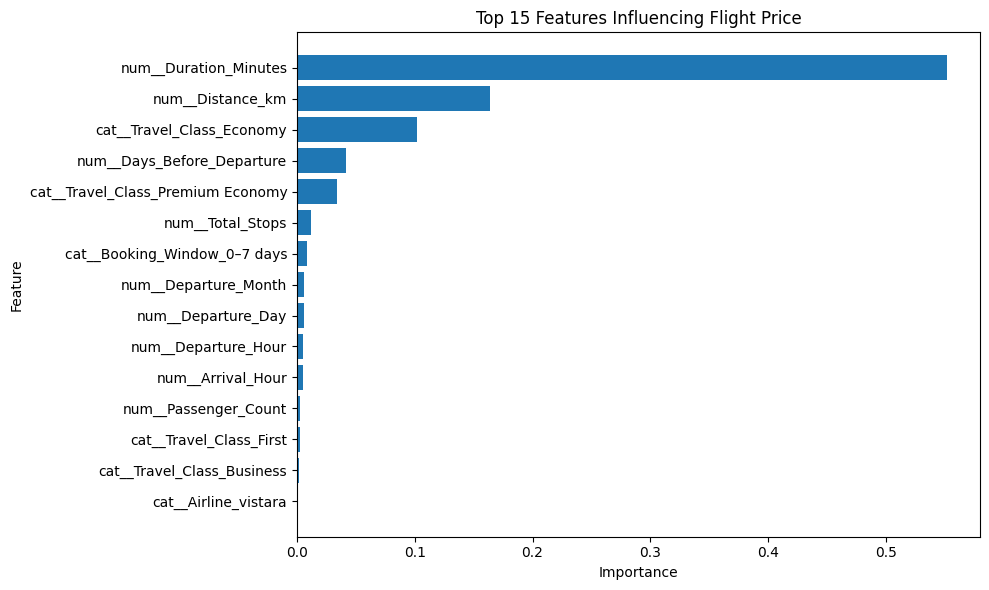

In [101]:
top_features = feature_importance.head(15).sort_values(
    'Importance'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features Influencing Flight Price')

plt.tight_layout()
plt.show()

In [102]:
from sklearn.ensemble import HistGradientBoostingRegressor

gradient_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

In [103]:
gradient_model.fit(X_train, y_train)

TypeError: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

In [104]:
gradient_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False
                ))
            ]),
            categorical_features
        )
    ]
)

In [105]:
gradient_model = Pipeline(
    steps=[
        ('preprocessor', gradient_preprocessor),
        ('model', HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

In [106]:
gradient_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Departure_Year',
                                                   'Departure_Month',
                                                   'Departure_Day',
                                                   'Departure_Hour',
                                                   'Arrival_Hour',
                                                   'Duration_Minutes',
                                                   'Total_Stops', 'Distance_km',
                                                   'Days_Before_Departure',
                                                   'Passenger_Count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Airline', 'Source',
                                                   'Destination',
                                                   'Travel_Class', 'Season',
                                                   'Weekday', 'Aircraft_Type',
                                                   'Booking_Channel',
                                                   'Departure_Period',
                                                   'Booking_Window'])])),
                ('model',
                 HistGradientBoostingRegressor(learning_rate=0.08, max_iter=200,
                                               random_state=42))])

In [107]:
y_pred_gradient = gradient_model.predict(X_test)

mae_gradient = mean_absolute_error(y_test, y_pred_gradient)

rmse_gradient = np.sqrt(
    mean_squared_error(y_test, y_pred_gradient)
)

r2_gradient = r2_score(y_test, y_pred_gradient)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", mae_gradient)
print("RMSE:", rmse_gradient)
print("R²  :", r2_gradient)

Gradient Boosting Results
-------------------------
MAE : 14659.31833933364
RMSE: 48221.481750679945
R²  : 0.6267485364546383


In [108]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_gradient
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_gradient
    ],
    'R2': [
        r2_linear,
        r2_rf,
        r2_gradient
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,23260.896620,52261.736366,0.561582
1,Random Forest,15419.459372,48941.108869,0.615525
2,Gradient Boosting,14659.318339,48221.481751,0.626749


In [110]:
plt.savefig(
    '/content/drive/MyDrive/top_15_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [111]:
import joblib

joblib.dump(
    gradient_model,
    '/content/drive/MyDrive/ai_travel_analyst_model.pkl'
)

print("Final model saved successfully!")

Final model saved successfully!


In [112]:
results.to_csv(
    '/content/drive/MyDrive/ai_travel_model_comparison.csv',
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [113]:
def predict_flight_price(
    airline,
    source,
    destination,
    departure_date,
    departure_hour,
    arrival_hour,
    duration_minutes,
    total_stops,
    distance_km,
    travel_class,
    days_before_departure,
    season,
    weekday,
    aircraft_type,
    booking_channel,
    passenger_count
):

    # Create a single-row dataframe
    input_data = pd.DataFrame({
        'Airline': [airline],
        'Source': [source],
        'Destination': [destination],
        'Departure_Date': [pd.to_datetime(departure_date)],
        'Departure_Hour': [departure_hour],
        'Arrival_Hour': [arrival_hour],
        'Duration_Minutes': [duration_minutes],
        'Total_Stops': [total_stops],
        'Distance_km': [distance_km],
        'Travel_Class': [travel_class],
        'Days_Before_Departure': [days_before_departure],
        'Season': [season],
        'Weekday': [weekday],
        'Aircraft_Type': [aircraft_type],
        'Booking_Channel': [booking_channel],
        'Passenger_Count': [passenger_count]
    })

    # Feature engineering
    input_data['Departure_Year'] = input_data['Departure_Date'].dt.year
    input_data['Departure_Month'] = input_data['Departure_Date'].dt.month
    input_data['Departure_Day'] = input_data['Departure_Date'].dt.day

    # Departure period
    if departure_hour < 6:
        departure_period = 'Night'
    elif departure_hour < 12:
        departure_period = 'Morning'
    elif departure_hour < 18:
        departure_period = 'Afternoon'
    else:
        departure_period = 'Evening'

    input_data['Departure_Period'] = departure_period

    # Booking window
    if days_before_departure <= 7:
        booking_window = '0-7 days'
    elif days_before_departure <= 30:
        booking_window = '8-30 days'
    elif days_before_departure <= 60:
        booking_window = '31-60 days'
    elif days_before_departure <= 90:
        booking_window = '61-90 days'
    else:
        booking_window = '91+ days'

    input_data['Booking_Window'] = booking_window

    # Keep exactly the features used during training
    input_data = input_data[features]

    # Predict
    predicted_price = gradient_model.predict(input_data)[0]

    return predicted_price

In [114]:
predicted_price = predict_flight_price(
    airline='qatar airways',
    source='Delhi',
    destination='London',
    departure_date='2026-12-15',
    departure_hour=10,
    arrival_hour=18,
    duration_minutes=540,
    total_stops=1,
    distance_km=6700,
    travel_class='Economy',
    days_before_departure=30,
    season='Winter',
    weekday='Tuesday',
    aircraft_type='Boeing 777',
    booking_channel='Online',
    passenger_count=1
)

print("Predicted Flight Price: ₹{:,.2f}".format(predicted_price))

Predicted Flight Price: ₹68,773.67


In [115]:
def get_price_benchmark(
    source,
    destination,
    travel_class,
    days_before_departure
):

    benchmark_df = clean_df[
        (clean_df['Source'].astype(str).str.lower() == source.lower()) &
        (clean_df['Destination'].astype(str).str.lower() == destination.lower()) &
        (clean_df['Travel_Class'].astype(str).str.lower() == travel_class.lower())
    ].copy()

    # If exact route/class has too few records,
    # fall back to travel class only
    if len(benchmark_df) < 20:
        benchmark_df = clean_df[
            clean_df['Travel_Class'].astype(str).str.lower()
            == travel_class.lower()
        ].copy()

    # Compare with similar booking window
    benchmark_df['Days_Difference'] = abs(
        benchmark_df['Days_Before_Departure']
        - days_before_departure
    )

    benchmark_df = benchmark_df.sort_values(
        'Days_Difference'
    ).head(100)

    median_price = benchmark_df['Price'].median()

    return median_price, len(benchmark_df)

In [116]:
historical_median, sample_count = get_price_benchmark(
    source='Delhi',
    destination='London',
    travel_class='Economy',
    days_before_departure=30
)

print("Historical Median Price: ₹{:,.2f}".format(historical_median))
print("Comparable Flights Used:", sample_count)

Historical Median Price: ₹75,710.96
Comparable Flights Used: 100


In [117]:
price_difference = predicted_price - historical_median

price_difference_percentage = (
    price_difference / historical_median
) * 100

print("Predicted Price: ₹{:,.2f}".format(predicted_price))
print("Historical Median: ₹{:,.2f}".format(historical_median))
print("Difference: ₹{:,.2f}".format(price_difference))
print("Difference Percentage: {:.2f}%".format(price_difference_percentage))

Predicted Price: ₹68,773.67
Historical Median: ₹75,710.96
Difference: ₹-6,937.29
Difference Percentage: -9.16%


In [118]:
if price_difference_percentage <= -10:
    price_status = "GOOD DEAL"
    recommendation = "The predicted price is significantly below the historical median. Booking now may be a good option."

elif price_difference_percentage <= 10:
    price_status = "AVERAGE PRICE"
    recommendation = "The predicted price is close to the historical median. The price appears reasonable."

else:
    price_status = "HIGH PRICE"
    recommendation = "The predicted price is above the historical median. Consider comparing other dates or airlines."

print("Price Status:", price_status)
print("AI Recommendation:", recommendation)

Price Status: AVERAGE PRICE
AI Recommendation: The predicted price is close to the historical median. The price appears reasonable.


In [119]:
print("=" * 55)
print("             ✈️ AI TRAVEL ANALYST")
print("=" * 55)

print(f"Route: Delhi → London")
print(f"Travel Class: Economy")
print(f"Days Before Departure: 30")

print("-" * 55)

print(f"Predicted Price      : ₹{predicted_price:,.2f}")
print(f"Historical Median    : ₹{historical_median:,.2f}")
print(f"Price Difference     : ₹{price_difference:,.2f}")
print(f"Difference           : {price_difference_percentage:.2f}%")

print("-" * 55)

print(f"Price Status         : {price_status}")
print(f"Recommendation       : {recommendation}")

print(f"Comparable Flights   : {sample_count}")

print("=" * 55)

             ✈️ AI TRAVEL ANALYST
Route: Delhi → London
Travel Class: Economy
Days Before Departure: 30
-------------------------------------------------------
Predicted Price      : ₹68,773.67
Historical Median    : ₹75,710.96
Price Difference     : ₹-6,937.29
Difference           : -9.16%
-------------------------------------------------------
Price Status         : AVERAGE PRICE
Recommendation       : The predicted price is close to the historical median. The price appears reasonable.
Comparable Flights   : 100


In [120]:
# Select flights comparable to the user's request

comparable_flights = clean_df[
    (clean_df['Source'].astype(str).str.lower() == 'delhi') &
    (clean_df['Destination'].astype(str).str.lower() == 'london') &
    (clean_df['Travel_Class'].astype(str).str.lower() == 'economy')
].copy()

print("Comparable flights found:", len(comparable_flights))

Comparable flights found: 101


In [121]:
if len(comparable_flights) < 20:
    print("Not enough comparable flights for a reliable benchmark.")
else:
    print("Enough comparable flights available.")

Enough comparable flights available.


In [122]:
price_percentiles = comparable_flights['Price'].dropna().quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
)

print("Price Percentiles")
print("-----------------")
print("10th percentile :", price_percentiles[0.10])
print("25th percentile :", price_percentiles[0.25])
print("50th percentile :", price_percentiles[0.50])
print("75th percentile :", price_percentiles[0.75])
print("90th percentile :", price_percentiles[0.90])

Price Percentiles
-----------------
10th percentile : 53614.687
25th percentile : 60467.03
50th percentile : 76169.0
75th percentile : 92214.6725
90th percentile : 111850.09800000006


In [123]:
price_percentile = (
    comparable_flights['Price'].dropna() < predicted_price
).mean() * 100

print(f"Predicted Price: ₹{predicted_price:,.2f}")
print(f"Price Percentile: {price_percentile:.2f}")

Predicted Price: ₹68,773.67
Price Percentile: 38.89


In [124]:
deal_score = 100 - price_percentile

deal_score = max(0, min(100, deal_score))

print(f"Deal Score: {deal_score:.1f}/100")

Deal Score: 61.1/100


In [125]:
if deal_score >= 80:
    recommendation = "EXCELLENT DEAL — Consider booking now."
    status = "EXCELLENT"

elif deal_score >= 65:
    recommendation = "GOOD DEAL — The price is below most comparable flights."
    status = "GOOD"

elif deal_score >= 40:
    recommendation = "FAIR PRICE — The price is around the historical range."
    status = "FAIR"

elif deal_score >= 20:
    recommendation = "EXPENSIVE — Consider checking other dates or airlines."
    status = "EXPENSIVE"

else:
    recommendation = "VERY EXPENSIVE — Waiting or comparing alternatives may be better."
    status = "VERY EXPENSIVE"


print("Status:", status)
print("Recommendation:", recommendation)

Status: FAIR
Recommendation: FAIR PRICE — The price is around the historical range.


In [126]:
print("=" * 60)
print("                 ✈️ AI TRAVEL ANALYST")
print("=" * 60)

print(f"Route                : Delhi → London")
print(f"Travel Class         : Economy")
print(f"Days Before Departure: 30")

print("-" * 60)

print(f"Predicted Price      : ₹{predicted_price:,.2f}")
print(f"Historical Median    : ₹{historical_median:,.2f}")
print(f"Price Difference     : ₹{price_difference:,.2f}")
print(f"Difference           : {price_difference_percentage:.2f}%")

print("-" * 60)

print(f"Price Percentile     : {price_percentile:.2f}")
print(f"Deal Score           : {deal_score:.1f}/100")
print(f"Price Status         : {status}")

print("-" * 60)

print(f"Recommendation       : {recommendation}")
print(f"Comparable Flights   : {sample_count}")

print("=" * 60)

                 ✈️ AI TRAVEL ANALYST
Route                : Delhi → London
Travel Class         : Economy
Days Before Departure: 30
------------------------------------------------------------
Predicted Price      : ₹68,773.67
Historical Median    : ₹75,710.96
Price Difference     : ₹-6,937.29
Difference           : -9.16%
------------------------------------------------------------
Price Percentile     : 38.89
Deal Score           : 61.1/100
Price Status         : FAIR
------------------------------------------------------------
Recommendation       : FAIR PRICE — The price is around the historical range.
Comparable Flights   : 100


In [127]:
def booking_window(days):
    if days <= 7:
        return "0-7 days"
    elif days <= 30:
        return "8-30 days"
    elif days <= 60:
        return "31-60 days"
    elif days <= 90:
        return "61-90 days"
    else:
        return "91+ days"


clean_df['Booking_Window'] = clean_df['Days_Before_Departure'].apply(
    booking_window
)

print(clean_df['Booking_Window'].value_counts())

Booking_Window
8-30 days     34270
0-7 days      23848
91+ days      18193
31-60 days    17660
61-90 days     4068
Name: count, dtype: int64


In [128]:
booking_analysis = (
    clean_df
    .groupby('Booking_Window')['Price']
    .agg(['count', 'median', 'mean'])
    .reindex([
        '0-7 days',
        '8-30 days',
        '31-60 days',
        '61-90 days',
        '91+ days'
    ])
)

booking_analysis

,count,median,mean
Booking_Window,,,
0-7 days,21916,68093.435,89755.707201
8-30 days,31549,48157.910,72204.453372
31-60 days,16284,39133.925,62572.236364
61-90 days,3755,39685.130,62173.631720
91+ days,16754,42730.965,65284.241163


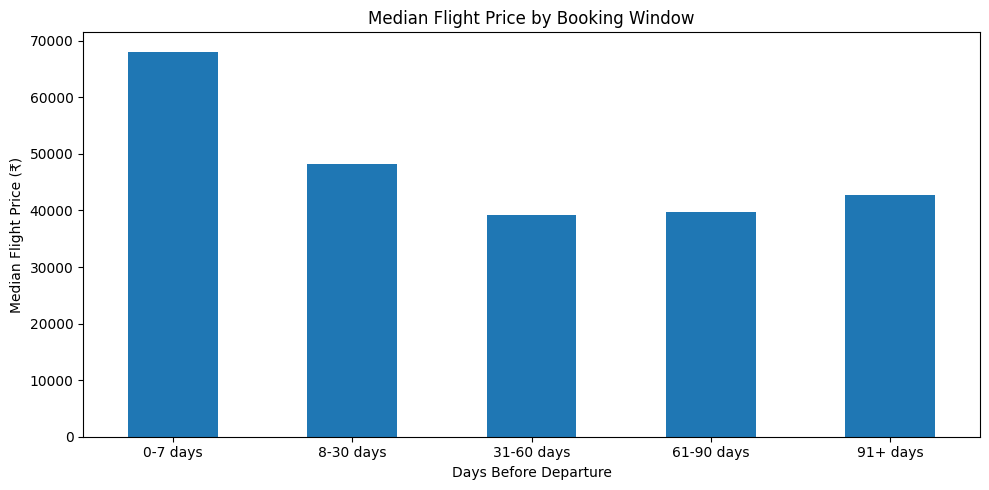

In [129]:
plt.figure(figsize=(10, 5))

booking_analysis['median'].plot(kind='bar')

plt.title('Median Flight Price by Booking Window')
plt.xlabel('Days Before Departure')
plt.ylabel('Median Flight Price (₹)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [130]:
current_days = 30

current_window = booking_window(current_days)

current_window_median = booking_analysis.loc[
    current_window, 'median'
]

print("Current Booking Window:", current_window)
print(
    "Historical Median for this Window: "
    f"₹{current_window_median:,.2f}"
)

Current Booking Window: 8-30 days
Historical Median for this Window: ₹48,157.91


In [131]:
window_difference = (
    predicted_price - current_window_median
)

window_difference_percentage = (
    window_difference / current_window_median
) * 100

print(f"Predicted Price: ₹{predicted_price:,.2f}")
print(
    f"Booking Window Median: "
    f"₹{current_window_median:,.2f}"
)
print(
    f"Difference: "
    f"₹{window_difference:,.2f}"
)
print(
    f"Difference Percentage: "
    f"{window_difference_percentage:.2f}%"
)

Predicted Price: ₹68,773.67
Booking Window Median: ₹48,157.91
Difference: ₹20,615.76
Difference Percentage: 42.81%


In [132]:
if deal_score >= 75:
    booking_recommendation = (
        "BOOK NOW — The predicted price is "
        "historically attractive."
    )

elif deal_score >= 60:
    booking_recommendation = (
        "CONSIDER BOOKING — The price is "
        "reasonably favorable."
    )

elif deal_score >= 40:
    booking_recommendation = (
        "COMPARE OPTIONS — The price is "
        "within the normal historical range."
    )

else:
    booking_recommendation = (
        "CONSIDER ALTERNATIVES — The price "
        "appears relatively expensive."
    )

print(booking_recommendation)

CONSIDER BOOKING — The price is reasonably favorable.


In [133]:
similar_flights = clean_df[
    (clean_df['Source'].astype(str).str.lower() == 'delhi') &
    (clean_df['Destination'].astype(str).str.lower() == 'london') &
    (clean_df['Travel_Class'].astype(str).str.lower() == 'economy') &
    (clean_df['Days_Before_Departure'].between(23, 37))
].copy()

print("Similar flights found:", len(similar_flights))

Similar flights found: 16


In [134]:
if len(similar_flights) >= 20:

    similar_median = similar_flights['Price'].median()

    similar_percentile = (
        similar_flights['Price'] < predicted_price
    ).mean() * 100

    print(f"Similar Flight Median : ₹{similar_median:,.2f}")
    print(f"Price Percentile      : {similar_percentile:.2f}")
    print(f"Comparable Flights    : {len(similar_flights)}")

else:
    print("Not enough similar historical flights.")

Not enough similar historical flights.


In [136]:
similar_flights = clean_df[
    (clean_df['Source'].astype(str).str.lower() == 'delhi') &
    (clean_df['Destination'].astype(str).str.lower() == 'london') &
    (clean_df['Travel_Class'].astype(str).str.lower() == 'economy') &
    (clean_df['Days_Before_Departure'].between(23, 37))
].copy()

print("Similar flights found:", len(similar_flights))

Similar flights found: 16


In [137]:
if len(similar_flights) >= 20:

    similar_median = similar_flights['Price'].median()

    similar_percentile = (
        similar_flights['Price'] < predicted_price
    ).mean() * 100

    print(f"Similar Flight Median : ₹{similar_median:,.2f}")
    print(f"Price Percentile      : {similar_percentile:.2f}")
    print(f"Comparable Flights    : {len(similar_flights)}")

else:
    print("Not enough similar historical flights.")

Not enough similar historical flights.


In [138]:
similar_deal_score = 100 - similar_percentile

similar_deal_score = max(
    0,
    min(100, similar_deal_score)
)

print(f"Similar-Flight Deal Score: {similar_deal_score:.1f}/100")

NameError: name 'similar_percentile' is not defined

In [139]:
print("Delhi flights:",
      (clean_df['Source'].astype(str).str.lower() == 'delhi').sum())

print("London flights:",
      (clean_df['Destination'].astype(str).str.lower() == 'london').sum())

print("Economy flights:",
      (clean_df['Travel_Class'].astype(str).str.lower() == 'economy').sum())

Delhi flights: 3299
London flights: 3377
Economy flights: 63604


In [140]:
similar_flights = clean_df[
    (clean_df['Source'].astype(str).str.lower() == 'delhi') &
    (clean_df['Destination'].astype(str).str.lower() == 'london') &
    (clean_df['Travel_Class'].astype(str).str.lower() == 'economy') &
    (clean_df['Days_Before_Departure'].between(0, 60))
].copy()

print("Similar flights found:", len(similar_flights))

Similar flights found: 82


In [141]:
if len(similar_flights) > 0:

    similar_median = similar_flights['Price'].median()

    similar_percentile = (
        similar_flights['Price'] < predicted_price
    ).mean() * 100

    print(f"Similar Flight Median : ₹{similar_median:,.2f}")
    print(f"Price Percentile      : {similar_percentile:.2f}")
    print(f"Comparable Flights    : {len(similar_flights)}")

else:
    print("No similar historical flights found.")

Similar Flight Median : ₹79,057.01
Price Percentile      : 28.05
Comparable Flights    : 82


In [142]:
similar_deal_score = 100 - similar_percentile

similar_deal_score = max(
    0,
    min(100, similar_deal_score)
)

print(f"Similar-Flight Deal Score: {similar_deal_score:.1f}/100")

Similar-Flight Deal Score: 72.0/100


In [143]:
if similar_deal_score >= 75:
    final_recommendation = (
        "BOOK NOW — This price is lower than most "
        "similar historical flights."
    )

elif similar_deal_score >= 60:
    final_recommendation = (
        "CONSIDER BOOKING — This price is reasonably "
        "favorable compared with similar flights."
    )

elif similar_deal_score >= 40:
    final_recommendation = (
        "COMPARE OPTIONS — The price is within the "
        "normal range for similar flights."
    )

else:
    final_recommendation = (
        "CONSIDER ALTERNATIVES — Similar historical "
        "flights were generally cheaper."
    )

print(final_recommendation)

CONSIDER BOOKING — This price is reasonably favorable compared with similar flights.


In [144]:
def ai_travel_analyst(
    airline,
    source,
    destination,
    departure_date,
    departure_hour,
    arrival_hour,
    duration_minutes,
    total_stops,
    distance_km,
    travel_class,
    days_before_departure,
    season,
    weekday,
    aircraft_type,
    booking_channel,
    passenger_count
):

    # -----------------------------------------
    # 1. PREDICT FLIGHT PRICE
    # -----------------------------------------

    predicted_price = predict_flight_price(
        airline=airline,
        source=source,
        destination=destination,
        departure_date=departure_date,
        departure_hour=departure_hour,
        arrival_hour=arrival_hour,
        duration_minutes=duration_minutes,
        total_stops=total_stops,
        distance_km=distance_km,
        travel_class=travel_class,
        days_before_departure=days_before_departure,
        season=season,
        weekday=weekday,
        aircraft_type=aircraft_type,
        booking_channel=booking_channel,
        passenger_count=passenger_count
    )

    # -----------------------------------------
    # 2. FIND HISTORICAL BENCHMARK
    # -----------------------------------------

    historical_median, sample_count = get_price_benchmark(
        source=source,
        destination=destination,
        travel_class=travel_class,
        days_before_departure=days_before_departure
    )

    # -----------------------------------------
    # 3. PRICE DIFFERENCE
    # -----------------------------------------

    price_difference = predicted_price - historical_median

    difference_percentage = (
        price_difference / historical_median
    ) * 100

    # -----------------------------------------
    # 4. FIND SIMILAR HISTORICAL FLIGHTS
    # -----------------------------------------

    similar_flights = clean_df[
        (clean_df['Source'].astype(str).str.lower() == source.lower()) &
        (clean_df['Destination'].astype(str).str.lower() == destination.lower()) &
        (clean_df['Travel_Class'].astype(str).str.lower() == travel_class.lower()) &
        (clean_df['Days_Before_Departure'].between(
            max(0, days_before_departure - 30),
            days_before_departure + 30
        ))
    ].copy()

    # -----------------------------------------
    # 5. PERCENTILE AND DEAL SCORE
    # -----------------------------------------

    if len(similar_flights) > 0:

        similar_median = similar_flights['Price'].median()

        similar_percentile = (
            similar_flights['Price'] < predicted_price
        ).mean() * 100

        similar_deal_score = 100 - similar_percentile

        similar_deal_score = max(
            0,
            min(100, similar_deal_score)
        )

    else:

        similar_median = None
        similar_percentile = None
        similar_deal_score = None

    # -----------------------------------------
    # 6. BOOKING RECOMMENDATION
    # -----------------------------------------

    if similar_deal_score is not None:

        if similar_deal_score >= 75:

            final_recommendation = (
                "BOOK NOW - This price is lower than most "
                "similar historical flights."
            )

        elif similar_deal_score >= 60:

            final_recommendation = (
                "CONSIDER BOOKING - This price is reasonably "
                "favorable compared with similar flights."
            )

        elif similar_deal_score >= 40:

            final_recommendation = (
                "COMPARE OPTIONS - The price is within the "
                "normal range for similar flights."
            )

        else:

            final_recommendation = (
                "CONSIDER ALTERNATIVES - Similar historical "
                "flights were generally cheaper."
            )

    else:

        final_recommendation = (
            "INSUFFICIENT DATA - Not enough similar historical "
            "flights for a reliable comparison."
        )

    # -----------------------------------------
    # 7. DISPLAY FINAL REPORT
    # -----------------------------------------

    print("=" * 70)
    print("✈️  AI TRAVEL ANALYST")
    print("=" * 70)

    print(f"Route                  : {source} → {destination}")
    print(f"Airline                : {airline}")
    print(f"Travel Class           : {travel_class}")
    print(f"Days Before Departure  : {days_before_departure}")

    print("-" * 70)

    print(f"Predicted Price        : ₹{predicted_price:,.2f}")
    print(f"Historical Median      : ₹{historical_median:,.2f}")
    print(f"Price Difference       : ₹{price_difference:,.2f}")
    print(f"Difference             : {difference_percentage:.2f}%")

    print("-" * 70)

    if similar_percentile is not None:

        print(
            f"Similar Flight Median : "
            f"₹{similar_median:,.2f}"
        )

        print(
            f"Price Percentile      : "
            f"{similar_percentile:.2f}"
        )

        print(
            f"Deal Score             : "
            f"{similar_deal_score:.1f}/100"
        )

        print(
            f"Comparable Flights     : "
            f"{len(similar_flights)}"
        )

    print("-" * 70)

    print("FINAL RECOMMENDATION")
    print(final_recommendation)

    print("=" * 70)

    return {
        "predicted_price": predicted_price,
        "historical_median": historical_median,
        "price_difference": price_difference,
        "difference_percentage": difference_percentage,
        "similar_flights": len(similar_flights),
        "similar_deal_score": similar_deal_score,
        "recommendation": final_recommendation
    }

In [145]:
final_result = ai_travel_analyst(
    airline='qatar airways',
    source='Delhi',
    destination='London',
    departure_date='2026-12-15',
    departure_hour=10,
    arrival_hour=18,
    duration_minutes=540,
    total_stops=1,
    distance_km=6700,
    travel_class='Economy',
    days_before_departure=30,
    season='Winter',
    weekday='Tuesday',
    aircraft_type='Boeing 777',
    booking_channel='Online',
    passenger_count=1
)

✈️  AI TRAVEL ANALYST
Route                  : Delhi → London
Airline                : qatar airways
Travel Class           : Economy
Days Before Departure  : 30
----------------------------------------------------------------------
Predicted Price        : ₹68,773.67
Historical Median      : ₹75,710.96
Price Difference       : ₹-6,937.29
Difference             : -9.16%
----------------------------------------------------------------------
Similar Flight Median : ₹79,057.01
Price Percentile      : 28.05
Deal Score             : 72.0/100
Comparable Flights     : 82
----------------------------------------------------------------------
FINAL RECOMMENDATION
CONSIDER BOOKING - This price is reasonably favorable compared with similar flights.


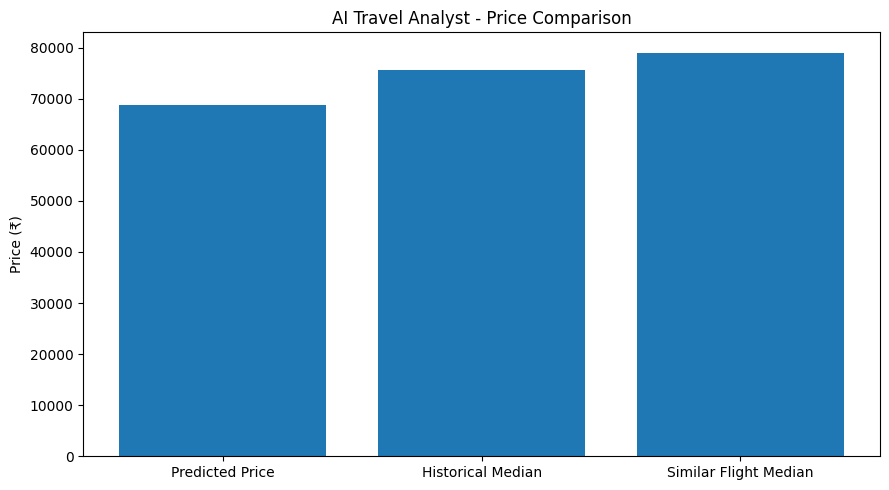

In [146]:
import matplotlib.pyplot as plt

labels = [
    'Predicted Price',
    'Historical Median',
    'Similar Flight Median'
]

values = [
    final_result['predicted_price'],
    final_result['historical_median'],
    similar_median
]

plt.figure(figsize=(9, 5))

plt.bar(labels, values)

plt.ylabel('Price (₹)')
plt.title('AI Travel Analyst - Price Comparison')

plt.tight_layout()
plt.show()

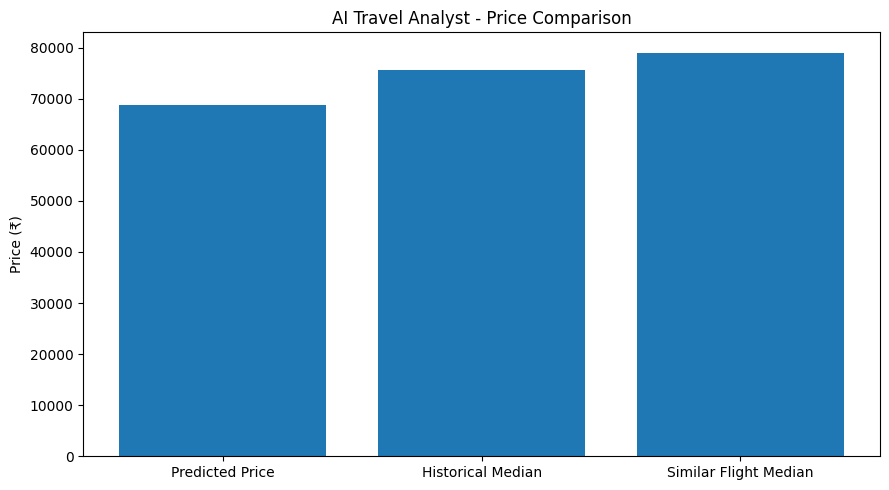

In [147]:
plt.figure(figsize=(9, 5))

plt.bar(labels, values)

plt.ylabel('Price (₹)')
plt.title('AI Travel Analyst - Price Comparison')

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/final_price_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [148]:
print("=" * 60)
print("AI TRAVEL ANALYST - FINAL MODEL SUMMARY")
print("=" * 60)

print("\nMODEL PERFORMANCE")
print(results.to_string(index=False))

print("\nBEST MODEL")
best_model = results.loc[
    results['R2'].idxmax()
]

print(best_model)

print("\nTOP FEATURES")
print(top_features.head(10).to_string(index=False))

print("\nFINAL PREDICTION")
print(f"Predicted Price: ₹{predicted_price:,.2f}")

print("=" * 60)

AI TRAVEL ANALYST - FINAL MODEL SUMMARY

MODEL PERFORMANCE
            Model          MAE         RMSE       R2
Linear Regression 23260.896620 52261.736366 0.561582
    Random Forest 15419.459372 48941.108869 0.615525
Gradient Boosting 14659.318339 48221.481751 0.626749

BEST MODEL
Model    Gradient Boosting
MAE           14659.318339
RMSE          48221.481751
R2                0.626749
Name: 2, dtype: object

TOP FEATURES
                     Feature  Importance
        cat__Airline_vistara    0.001191
  cat__Travel_Class_Business    0.001585
     cat__Travel_Class_First    0.002338
        num__Passenger_Count    0.002594
           num__Arrival_Hour    0.005003
         num__Departure_Hour    0.005469
          num__Departure_Day    0.005777
        num__Departure_Month    0.005951
cat__Booking_Window_0–7 days    0.008749
            num__Total_Stops    0.012254

FINAL PREDICTION
Predicted Price: ₹68,773.67


In [149]:
final_prediction = pd.DataFrame({
    'Airline': ['qatar airways'],
    'Source': ['Delhi'],
    'Destination': ['London'],
    'Travel_Class': ['Economy'],
    'Days_Before_Departure': [30],
    'Predicted_Price': [predicted_price],
    'Historical_Median': [historical_median],
    'Deal_Score': [similar_deal_score],
    'Comparable_Flights': [len(similar_flights)],
    'Recommendation': [final_recommendation]
})

final_prediction.to_csv(
    '/content/drive/MyDrive/final_prediction.csv',
    index=False
)

print("Final prediction saved successfully!")

Final prediction saved successfully!


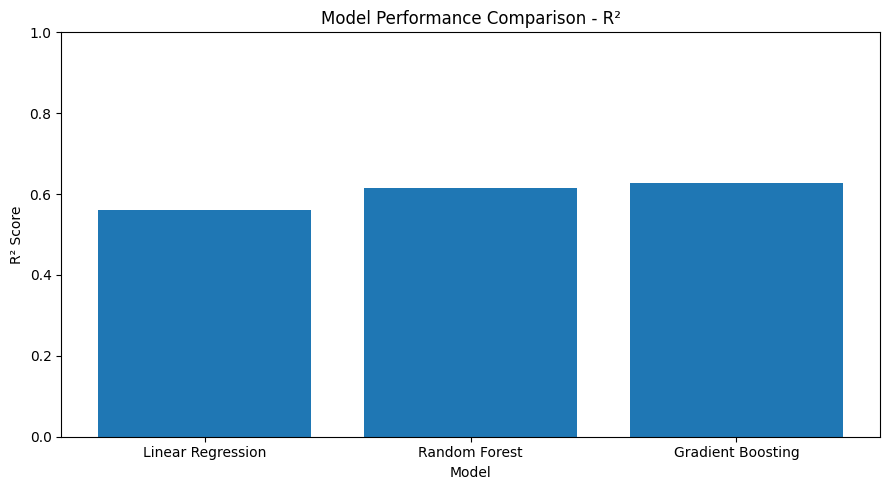

In [150]:
import matplotlib.pyplot as plt

# -----------------------------------------
# MODEL COMPARISON - R²
# -----------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    results['Model'],
    results['R2']
)

plt.ylabel('R² Score')
plt.xlabel('Model')
plt.title('Model Performance Comparison - R²')

plt.ylim(0, 1)

plt.tight_layout()

plt.show()

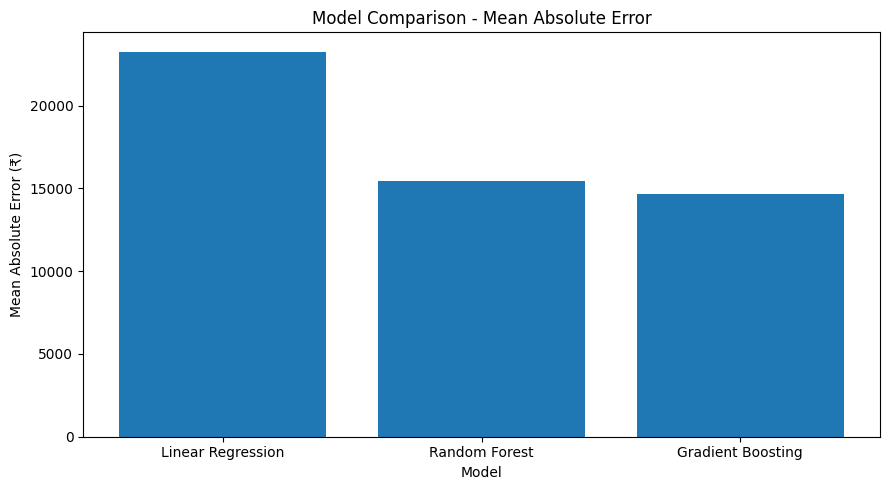

In [151]:
plt.figure(figsize=(9, 5))

plt.bar(
    results['Model'],
    results['MAE']
)

plt.ylabel('Mean Absolute Error (₹)')
plt.xlabel('Model')
plt.title('Model Comparison - Mean Absolute Error')

plt.tight_layout()

plt.show()

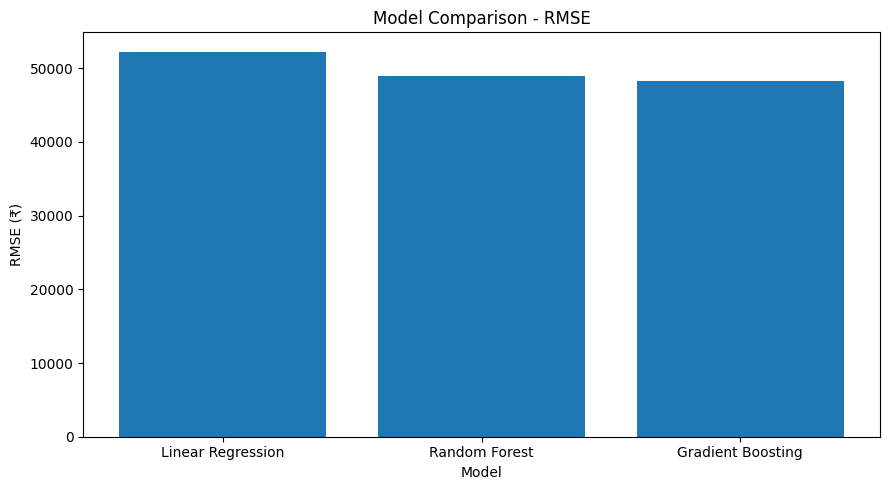

In [152]:
plt.figure(figsize=(9, 5))

plt.bar(
    results['Model'],
    results['RMSE']
)

plt.ylabel('RMSE (₹)')
plt.xlabel('Model')
plt.title('Model Comparison - RMSE')

plt.tight_layout()

plt.show()

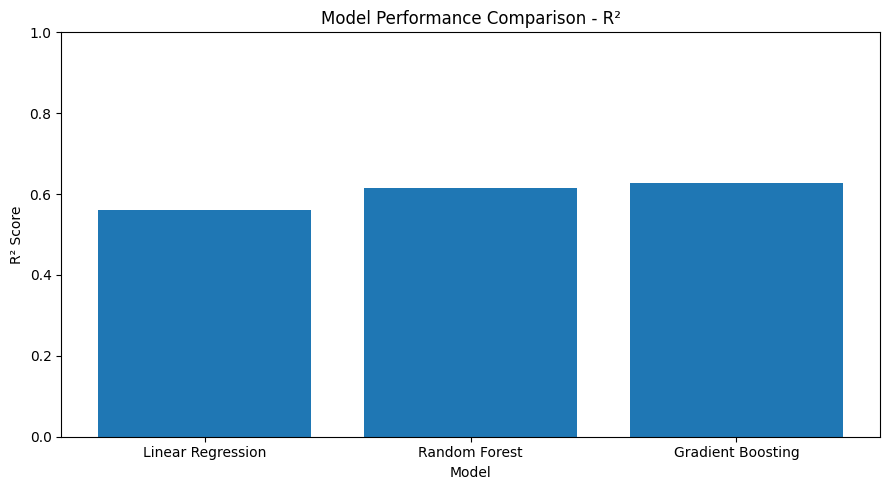

In [155]:
# R² graph
plt.figure(figsize=(9, 5))

plt.bar(results['Model'], results['R2'])

plt.ylabel('R² Score')
plt.xlabel('Model')
plt.title('Model Performance Comparison - R²')
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/model_comparison_r2.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


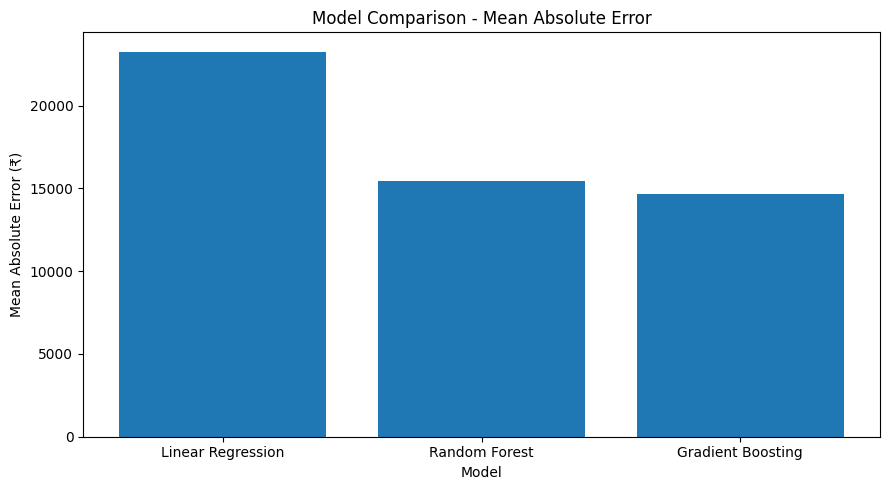

In [156]:
# MAE graph
plt.figure(figsize=(9, 5))

plt.bar(results['Model'], results['MAE'])

plt.ylabel('Mean Absolute Error (₹)')
plt.xlabel('Model')
plt.title('Model Comparison - Mean Absolute Error')

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/model_comparison_mae.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

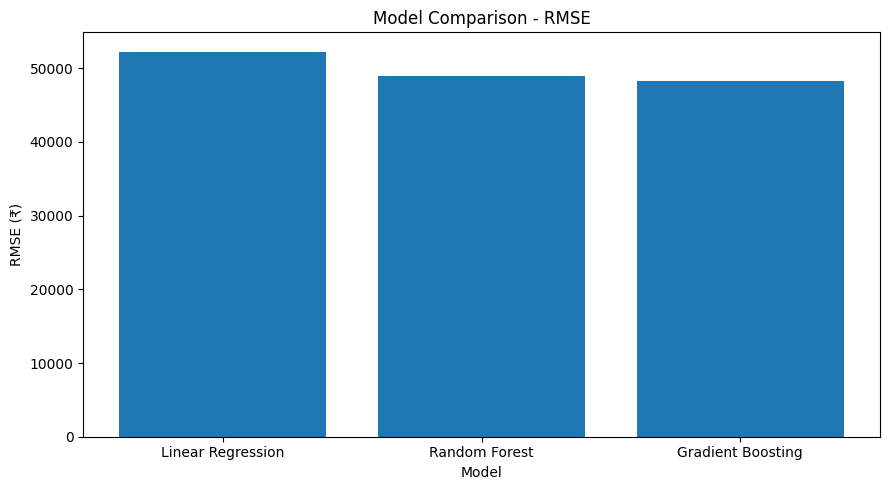

In [157]:
# RMSE graph
plt.figure(figsize=(9, 5))

plt.bar(results['Model'], results['RMSE'])

plt.ylabel('RMSE (₹)')
plt.xlabel('Model')
plt.title('Model Comparison - RMSE')

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/model_comparison_rmse.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [158]:
best_index = results['R2'].idxmax()

best_model_name = results.loc[best_index, 'Model']
best_mae = results.loc[best_index, 'MAE']
best_rmse = results.loc[best_index, 'RMSE']
best_r2 = results.loc[best_index, 'R2']

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Model : {best_model_name}")
print(f"MAE   : ₹{best_mae:,.2f}")
print(f"RMSE  : ₹{best_rmse:,.2f}")
print(f"R²    : {best_r2:.4f}")

print("=" * 60)

BEST MODEL
Model : Gradient Boosting
MAE   : ₹14,659.32
RMSE  : ₹48,221.48
R²    : 0.6267


In [160]:
predicted_price = predict_flight_price(
    airline='qatar airways',
    source='Delhi',
    destination='London',
    departure_date='2026-12-15',
    departure_hour=10,
    arrival_hour=18,
    duration_minutes=540,
    total_stops=1,
    distance_km=6700,
    travel_class='Economy',
    days_before_departure=30,
    season='Winter',
    weekday='Tuesday',
    aircraft_type='Boeing 777',
    booking_channel='Online',
    passenger_count=1
)

print(f"Predicted Flight Price: ₹{predicted_price:,.2f}")

Predicted Flight Price: ₹68,773.67


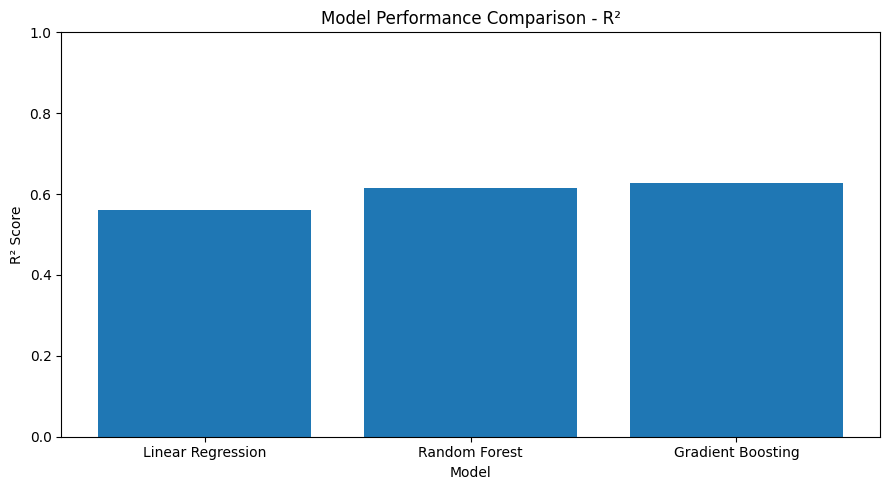

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    results['Model'],
    results['R2']
)

plt.ylabel('R² Score')
plt.xlabel('Model')
plt.title('Model Performance Comparison - R²')

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [162]:
booking_scenarios = [7, 15, 30, 45, 60, 90]

scenario_results = []

for days in booking_scenarios:

    price = predict_flight_price(
        airline='qatar airways',
        source='Delhi',
        destination='London',
        departure_date='2026-12-15',
        departure_hour=10,
        arrival_hour=18,
        duration_minutes=540,
        total_stops=1,
        distance_km=6700,
        travel_class='Economy',
        days_before_departure=days,
        season='Winter',
        weekday='Tuesday',
        aircraft_type='Boeing 777',
        booking_channel='Online',
        passenger_count=1
    )

    scenario_results.append({
        'Days_Before_Departure': days,
        'Predicted_Price': price
    })

scenario_df = pd.DataFrame(scenario_results)

scenario_df['Difference_From_Current'] = (
    scenario_df['Predicted_Price']
    - predicted_price
)

scenario_df

,Days_Before_Departure,Predicted_Price,Difference_From_Current
0,7,91971.658387,23197.989139
1,15,75801.182474,7027.513226
2,30,68773.669247,0.000000
3,45,61876.870323,-6896.798924
4,60,61876.870323,-6896.798924
5,90,61445.908835,-7327.760412


In [163]:
# Find the scenario with the lowest predicted price

best_scenario = scenario_df.loc[
    scenario_df['Predicted_Price'].idxmin()
]

best_days = int(best_scenario['Days_Before_Departure'])
best_price = best_scenario['Predicted_Price']

current_price = predicted_price

potential_saving = current_price - best_price

saving_percentage = (
    potential_saving / current_price
) * 100

print("=" * 65)
print("🧠 AI BOOKING OPTIMIZER")
print("=" * 65)

print(f"Current Booking Point : {30} days before departure")
print(f"Current Predicted Price: ₹{current_price:,.2f}")

print("-" * 65)

print(f"Best Tested Booking Point : {best_days} days before departure")
print(f"Predicted Price            : ₹{best_price:,.2f}")
print(f"Potential Saving           : ₹{potential_saving:,.2f}")
print(f"Potential Saving (%)       : {saving_percentage:.2f}%")

print("-" * 65)

if potential_saving > 0:
    print(
        f"💡 AI INSIGHT: Booking around {best_days} days "
        f"before departure gives the lowest predicted price "
        f"among the tested scenarios."
    )
else:
    print(
        "💡 AI INSIGHT: The current booking point is already "
        "the best among the tested scenarios."
    )

print("=" * 65)

🧠 AI BOOKING OPTIMIZER
Current Booking Point : 30 days before departure
Current Predicted Price: ₹68,773.67
-----------------------------------------------------------------
Best Tested Booking Point : 90 days before departure
Predicted Price            : ₹61,445.91
Potential Saving           : ₹7,327.76
Potential Saving (%)       : 10.65%
-----------------------------------------------------------------
💡 AI INSIGHT: Booking around 90 days before departure gives the lowest predicted price among the tested scenarios.


In [164]:
import itertools
import pandas as pd

# Base flight information
base_flight = {
    'airline': 'qatar airways',
    'source': 'Delhi',
    'destination': 'London',
    'departure_date': '2026-12-15',
    'departure_hour': 10,
    'arrival_hour': 18,
    'duration_minutes': 540,
    'distance_km': 6700,
    'season': 'Winter',
    'weekday': 'Tuesday',
    'aircraft_type': 'Boeing 777',
    'booking_channel': 'Online',
    'passenger_count': 1
}

# Values we want to test
booking_days = [7, 15, 30, 45, 60, 90]

travel_classes = [
    'Economy',
    'Premium Economy',
    'Business',
    'First'
]

stops_options = [0, 1, 2]

scenarios = []

for days, travel_class, stops in itertools.product(
    booking_days,
    travel_classes,
    stops_options
):

    price = predict_flight_price(
        airline=base_flight['airline'],
        source=base_flight['source'],
        destination=base_flight['destination'],
        departure_date=base_flight['departure_date'],
        departure_hour=base_flight['departure_hour'],
        arrival_hour=base_flight['arrival_hour'],
        duration_minutes=base_flight['duration_minutes'],
        total_stops=stops,
        distance_km=base_flight['distance_km'],
        travel_class=travel_class,
        days_before_departure=days,
        season=base_flight['season'],
        weekday=base_flight['weekday'],
        aircraft_type=base_flight['aircraft_type'],
        booking_channel=base_flight['booking_channel'],
        passenger_count=base_flight['passenger_count']
    )

    scenarios.append({
        'Days_Before_Departure': days,
        'Travel_Class': travel_class,
        'Stops': stops,
        'Predicted_Price': price
    })

scenario_search_df = pd.DataFrame(scenarios)

scenario_search_df = scenario_search_df.sort_values(
    'Predicted_Price'
).reset_index(drop=True)

scenario_search_df.head(15)

,Days_Before_Departure,Travel_Class,Stops,Predicted_Price
0,90,Economy,2,51677.060914
1,45,Economy,2,52108.022402
2,60,Economy,2,52108.022402
3,30,Economy,2,58047.218951
4,90,Economy,1,61445.908835
5,15,Economy,2,61462.609303
6,45,Economy,1,61876.870323
7,60,Economy,1,61876.870323
8,30,Economy,1,68773.669247
9,45,Economy,0,75401.301481


In [168]:
best_option = scenario_search_df.iloc[0]

print("=" * 70)
print(" AI MULTI-OBJECTIVE FLIGHT OPTIMIZER")
print("=" * 70)

print(f"Best Booking Time : "
      f"{int(best_option['Days_Before_Departure'])} days before departure")

print(f"Travel Class      : "
      f"{best_option['Travel_Class']}")

print(f"Number of Stops   : "
      f"{int(best_option['Stops'])}")

print(f"Predicted Price   : "
      f"₹{best_option['Predicted_Price']:,.2f}")

print("=" * 70)

 AI MULTI-OBJECTIVE FLIGHT OPTIMIZER
Best Booking Time : 90 days before departure
Travel Class      : Economy
Number of Stops   : 2
Predicted Price   : ₹51,677.06


In [169]:
current_price = predicted_price

best_price = best_option['Predicted_Price']

saving = current_price - best_price

saving_percentage = (saving / current_price) * 100

print("=" * 70)
print(" SAVING ANALYSIS")
print("=" * 70)

print(f"Current Flight Price : ₹{current_price:,.2f}")
print(f"Best AI Option       : ₹{best_price:,.2f}")
print(f"Potential Saving     : ₹{saving:,.2f}")
print(f"Saving Percentage    : {saving_percentage:.2f}%")

print("=" * 70)

 SAVING ANALYSIS
Current Flight Price : ₹68,773.67
Best AI Option       : ₹51,677.06
Potential Saving     : ₹17,096.61
Saving Percentage    : 24.86%


In [170]:
budget_options = scenario_search_df[
    scenario_search_df['Travel_Class'].isin(
        ['Economy', 'Premium Economy']
    )
].copy()

budget_best = budget_options.iloc[0]

print("=" * 70)
print(" BUDGET MODE")
print("=" * 70)

print(f"Recommended Class : {budget_best['Travel_Class']}")
print(f"Recommended Stops : {int(budget_best['Stops'])}")
print(
    f"Book Around       : "
    f"{int(budget_best['Days_Before_Departure'])} days before departure"
)
print(f"Predicted Price   : ₹{budget_best['Predicted_Price']:,.2f}")

print("=" * 70)

 BUDGET MODE
Recommended Class : Economy
Recommended Stops : 2
Book Around       : 90 days before departure
Predicted Price   : ₹51,677.06


In [171]:
comfort_options = scenario_search_df[
    (
        scenario_search_df['Travel_Class'].isin(
            ['Business', 'First']
        )
    )
    &
    (scenario_search_df['Stops'] <= 1)
].copy()

comfort_best = comfort_options.iloc[0]

print("=" * 70)
print("COMFORT MODE")
print("=" * 70)

print(f"Recommended Class : {comfort_best['Travel_Class']}")
print(f"Recommended Stops : {int(comfort_best['Stops'])}")
print(
    f"Book Around       : "
    f"{int(comfort_best['Days_Before_Departure'])} days before departure"
)
print(f"Predicted Price   : ₹{comfort_best['Predicted_Price']:,.2f}")

print("=" * 70)

COMFORT MODE
Recommended Class : Business
Recommended Stops : 1
Book Around       : 90 days before departure
Predicted Price   : ₹175,196.27


In [173]:
balanced_options = scenario_search_df.copy()

balanced_options['Price_Score'] = (
    1 -
    (
        balanced_options['Predicted_Price']
        /
        balanced_options['Predicted_Price'].max()
    )
)

balanced_options['Stop_Score'] = (
    1 - balanced_options['Stops'] / 2
)

balanced_options['Class_Score'] = (
    balanced_options['Travel_Class'].map({
        'Economy': 1.0,
        'Premium Economy': 0.8,
        'Business': 0.5,
        'First': 0.2
    })
)

balanced_options['Balanced_Score'] = (
    0.60 * balanced_options['Price_Score']
    +
    0.25 * balanced_options['Stop_Score']
    +
    0.15 * balanced_options['Class_Score']
)

balanced_best = balanced_options.sort_values(
    'Balanced_Score',
    ascending=False
).iloc[0]

print("=" * 70)
print(" BALANCED MODE")
print("=" * 70)

print(f"Recommended Class : {balanced_best['Travel_Class']}")
print(f"Recommended Stops : {int(balanced_best['Stops'])}")
print(
    f"Book Around       : "
    f"{int(balanced_best['Days_Before_Departure'])} days before departure"
)
print(f"Predicted Price   : ₹{balanced_best['Predicted_Price']:,.2f}")
print(f"Balanced Score    : "
      f"{balanced_best['Balanced_Score']:.3f}")

print("=" * 70)

 BALANCED MODE
Recommended Class : Economy
Recommended Stops : 0
Book Around       : 60 days before departure
Predicted Price   : ₹75,401.30
Balanced Score    : 0.780


In [175]:
print("=" * 75)
print(" AI EXPLANATION — WHY THIS OPTION?")
print("=" * 75)

print(
    f"The AI recommends {int(balanced_best['Days_Before_Departure'])} "
    f"days before departure."
)

print(
    f"\n Predicted Price: "
    f"₹{balanced_best['Predicted_Price']:,.2f}"
)

print(
    f" Travel Class: "
    f"{balanced_best['Travel_Class']}"
)

print(
    f" Stops: "
    f"{int(balanced_best['Stops'])}"
)

print(
    f"\n Balanced Score: "
    f"{balanced_best['Balanced_Score']:.3f}"
)

print("\nWhy this option was selected:")

print(
    "• Price was given the highest importance (60%)."
)

print(
    "• Number of stops was considered for convenience (25%)."
)

print(
    "• Travel class contributed to the comfort component (15%)."
)

print(
    "\nThe system therefore balances "
    "price, convenience and travel class "
    "instead of choosing only the cheapest flight."
)

print("=" * 75)

 AI EXPLANATION — WHY THIS OPTION?
The AI recommends 60 days before departure.

 Predicted Price: ₹75,401.30
 Travel Class: Economy
 Stops: 0

 Balanced Score: 0.780

Why this option was selected:
• Price was given the highest importance (60%).
• Number of stops was considered for convenience (25%).
• Travel class contributed to the comfort component (15%).

The system therefore balances price, convenience and travel class instead of choosing only the cheapest flight.


In [177]:
# Select a scenario to investigate
what_if = scenario_search_df[
    (scenario_search_df['Days_Before_Departure'] == 60) &
    (scenario_search_df['Travel_Class'] == 'Economy') &
    (scenario_search_df['Stops'] == 1)
].iloc[0]

what_if_price = what_if['Predicted_Price']

price_change = what_if_price - predicted_price

percentage_change = (
    price_change / predicted_price
) * 100

print("=" * 75)
print(" WHAT-IF TRAVEL SIMULATOR")
print("=" * 75)

print(f"Current Price        : ₹{predicted_price:,.2f}")

print(
    f"What-If Booking Time : "
    f"{int(what_if['Days_Before_Departure'])} days"
)

print(
    f"What-If Travel Class : "
    f"{what_if['Travel_Class']}"
)

print(
    f"What-If Stops        : "
    f"{int(what_if['Stops'])}"
)

print(
    f"What-If Price        : "
    f"₹{what_if_price:,.2f}"
)

print(
    f"Price Change         : "
    f"₹{price_change:,.2f}"
)

print(
    f"Percentage Change    : "
    f"{percentage_change:.2f}%"
)

print("=" * 75)

 WHAT-IF TRAVEL SIMULATOR
Current Price        : ₹68,773.67
What-If Booking Time : 60 days
What-If Travel Class : Economy
What-If Stops        : 1
What-If Price        : ₹61,876.87
Price Change         : ₹-6,896.80
Percentage Change    : -10.03%


In [178]:
if price_change < 0:

    print(
        f" INSIGHT: This change could save "
        f"₹{abs(price_change):,.2f}."
    )

elif price_change > 0:

    print(
        f" INSIGHT: This change could cost "
        f"₹{price_change:,.2f} more."
    )

else:

    print(
        "ℹ INSIGHT: This change has almost no "
        "effect on predicted price."
    )

 INSIGHT: This change could save ₹6,896.80.


In [180]:
model_r2 = r2_gradient

confidence_score = model_r2 * 100

if confidence_score >= 75:
    confidence_level = "HIGH"

elif confidence_score >= 60:
    confidence_level = "MEDIUM"

else:
    confidence_level = "LOW"

print("=" * 75)
print(" AI RECOMMENDATION CONFIDENCE")
print("=" * 75)

print(f"Model R²              : {model_r2:.3f}")
print(f"Confidence Indicator  : {confidence_score:.1f}/100")
print(f"Confidence Level      : {confidence_level}")

print("=" * 75)

 AI RECOMMENDATION CONFIDENCE
Model R²              : 0.627
Confidence Indicator  : 62.7/100
Confidence Level      : MEDIUM


In [183]:
print()
print("=" * 80)
print(" AI TRAVEL ANALYST — FINAL RECOMMENDATION")
print("=" * 80)

print(f"Route              : Delhi → London")
print(f"Current Booking    : 30 days before departure")
print(f"Current Price      : ₹{predicted_price:,.2f}")

print("-" * 80)

print(" RECOMMENDED OPTION")
print(
    f"Book Around        : "
    f"{int(balanced_best['Days_Before_Departure'])} days before departure"
)

print(
    f"Travel Class       : "
    f"{balanced_best['Travel_Class']}"
)

print(
    f"Stops              : "
    f"{int(balanced_best['Stops'])}"
)

print(
    f"Predicted Price    : "
    f"₹{balanced_best['Predicted_Price']:,.2f}"
)

print(
    f"Balanced Score     : "
    f"{balanced_best['Balanced_Score']:.3f}"
)

print("-" * 80)

print(" WHY?")

print(
    "The recommendation balances predicted price, "
    "number of stops and travel class."
)

print(
    f"Model Confidence Indicator : "
    f"{confidence_score:.1f}/100 ({confidence_level})"
)

print("-" * 80)

print(" AI DECISION")

if balanced_best['Predicted_Price'] < predicted_price:

    saving = predicted_price - balanced_best['Predicted_Price']

    print(
        f"Choose this option to save ₹{saving:,.2f} "
        f"({saving / predicted_price * 100:.2f}%)."
    )

else:

    extra = balanced_best['Predicted_Price'] - predicted_price

    print(
        f"This option costs ₹{extra:,.2f} more than the current prediction."
    )

    print(
        "However, it was selected because Balanced Mode "
        "considers price, stops and travel class together."
    )

print("=" * 80)


 AI TRAVEL ANALYST — FINAL RECOMMENDATION
Route              : Delhi → London
Current Booking    : 30 days before departure
Current Price      : ₹68,773.67
--------------------------------------------------------------------------------
 RECOMMENDED OPTION
Book Around        : 60 days before departure
Travel Class       : Economy
Stops              : 0
Predicted Price    : ₹75,401.30
Balanced Score     : 0.780
--------------------------------------------------------------------------------
 WHY?
The recommendation balances predicted price, number of stops and travel class.
Model Confidence Indicator : 62.7/100 (MEDIUM)
--------------------------------------------------------------------------------
 AI DECISION
This option costs ₹6,627.63 more than the current prediction.
However, it was selected because Balanced Mode considers price, stops and travel class together.


In [184]:
booking_days_range = list(range(1, 181))

price_predictions = []

for days in booking_days_range:

    price = predict_flight_price(
        airline='qatar airways',
        source='Delhi',
        destination='London',
        departure_date='2026-12-15',
        departure_hour=10,
        arrival_hour=18,
        duration_minutes=540,
        total_stops=1,
        distance_km=6700,
        travel_class='Economy',
        days_before_departure=days,
        season='Winter',
        weekday='Tuesday',
        aircraft_type='Boeing 777',
        booking_channel='Online',
        passenger_count=1
    )

    price_predictions.append(price)

price_curve = pd.DataFrame({
    'Days_Before_Departure': booking_days_range,
    'Predicted_Price': price_predictions
})

price_curve.head()

,Days_Before_Departure,Predicted_Price
0,1,114646.348206
1,2,114646.348206
2,3,114646.348206
3,4,93003.398048
4,5,93003.398048


In [186]:
best_curve_row = price_curve.loc[
    price_curve['Predicted_Price'].idxmin()
]

best_curve_days = int(
    best_curve_row['Days_Before_Departure']
)

best_curve_price = best_curve_row['Predicted_Price']

print("=" * 70)
print(" PRICE INTELLIGENCE ANALYSIS")
print("=" * 70)

print(
    f"Best predicted booking point : "
    f"{best_curve_days} days before departure"
)

print(
    f"Lowest predicted price       : "
    f"₹{best_curve_price:,.2f}"
)

print("=" * 70)

 PRICE INTELLIGENCE ANALYSIS
Best predicted booking point : 161 days before departure
Lowest predicted price       : ₹60,979.78


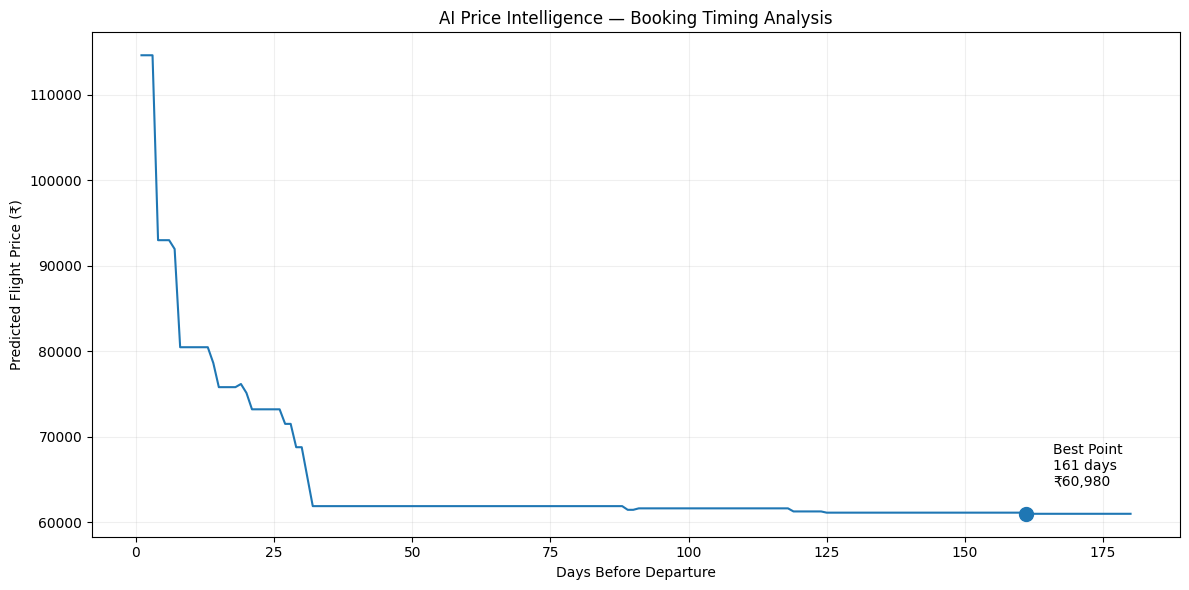

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    price_curve['Days_Before_Departure'],
    price_curve['Predicted_Price']
)

plt.scatter(
    best_curve_days,
    best_curve_price,
    s=100
)

plt.annotate(
    f"Best Point\n{best_curve_days} days\n₹{best_curve_price:,.0f}",
    (
        best_curve_days,
        best_curve_price
    ),
    xytext=(20, 20),
    textcoords='offset points'
)

plt.xlabel('Days Before Departure')
plt.ylabel('Predicted Flight Price (₹)')
plt.title('AI Price Intelligence — Booking Timing Analysis')

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [188]:
price_25 = price_curve['Predicted_Price'].quantile(0.25)
price_75 = price_curve['Predicted_Price'].quantile(0.75)

def classify_price(price):

    if price <= price_25:
        return "EXCELLENT DEAL"

    elif price <= price_75:
        return "FAIR PRICE"

    else:
        return "EXPENSIVE"

price_curve['Price_Zone'] = (
    price_curve['Predicted_Price']
    .apply(classify_price)
)

price_curve.head(20)

,Days_Before_Departure,Predicted_Price,Price_Zone
0,1,114646.348206,EXPENSIVE
1,2,114646.348206,EXPENSIVE
2,3,114646.348206,EXPENSIVE
3,4,93003.398048,EXPENSIVE
4,5,93003.398048,EXPENSIVE
5,6,93003.398048,EXPENSIVE
6,7,91971.658387,EXPENSIVE
7,8,80474.959496,EXPENSIVE
8,9,80474.959496,EXPENSIVE
9,10,80474.959496,EXPENSIVE


In [190]:
excellent_days = price_curve[
    price_curve['Price_Zone'] == 'EXCELLENT DEAL'
]

print("=" * 70)
print(" BOOKING SWEET SPOT")
print("=" * 70)

print(
    f"Excellent-deal booking window: "
    f"{excellent_days['Days_Before_Departure'].min()}–"
    f"{excellent_days['Days_Before_Departure'].max()} days"
)

print(
    f"Lowest predicted price: "
    f"₹{excellent_days['Predicted_Price'].min():,.2f}"
)

print("=" * 70)

 BOOKING SWEET SPOT
Excellent-deal booking window: 125–180 days
Lowest predicted price: ₹60,979.78


In [191]:
# ============================================================
# FINAL AI SYSTEM VARIABLES
# ============================================================

dashboard_data = {
    'route': 'Delhi → London',

    'departure_date': '2026-12-15',

    'current_days': 30,

    'current_price': predicted_price,

    'historical_median': historical_median,

    'deal_score': deal_score,

    'price_percentile': price_percentile,

    'best_booking_day': best_curve_days,

    'best_predicted_price': best_curve_price,

    'sweet_spot_start': int(
        excellent_days['Days_Before_Departure'].min()
    ),

    'sweet_spot_end': int(
        excellent_days['Days_Before_Departure'].max()
    ),

    'model_r2': r2_gradient,

    'best_model': 'Gradient Boosting'
}

dashboard_data

{'route': 'Delhi → London',
 'departure_date': '2026-12-15',
 'current_days': 30,
 'current_price': np.float64(68773.66924717874),
 'historical_median': 75710.96,
 'deal_score': np.float64(61.11111111111111),
 'price_percentile': np.float64(38.88888888888889),
 'best_booking_day': 161,
 'best_predicted_price': np.float64(60979.784437623326),
 'sweet_spot_start': 125,
 'sweet_spot_end': 180,
 'model_r2': 0.6267485364546383,
 'best_model': 'Gradient Boosting'}

In [192]:
potential_saving = (
    predicted_price -
    best_curve_price
)

potential_saving_percentage = (
    potential_saving /
    predicted_price
) * 100

print("Current Predicted Price : "
      f"₹{predicted_price:,.2f}")

print("Best Predicted Price    : "
      f"₹{best_curve_price:,.2f}")

print("Potential Saving        : "
      f"₹{potential_saving:,.2f}")

print("Potential Saving (%)    : "
      f"{potential_saving_percentage:.2f}%")

Current Predicted Price : ₹68,773.67
Best Predicted Price    : ₹60,979.78
Potential Saving        : ₹7,793.88
Potential Saving (%)    : 11.33%


In [193]:
if potential_saving_percentage >= 15:

    final_message = (
        "WAIT — Current booking appears expensive. "
        "The model identifies a significantly cheaper "
        "booking window."
    )

elif potential_saving_percentage >= 5:

    final_message = (
        "CONSIDER WAITING — A better price may be available "
        "within the recommended booking window."
    )

else:

    final_message = (
        "BOOKING NOW MAY BE REASONABLE — "
        "The potential price improvement is relatively small."
    )

print(final_message)

CONSIDER WAITING — A better price may be available within the recommended booking window.


In [195]:
print("=" * 80)
print(" AI TRAVEL ANALYST — TRAVELER INTELLIGENCE REPORT")
print("=" * 80)

print(f"Route                 : {dashboard_data['route']}")
print(f"Departure Date        : {dashboard_data['departure_date']}")

print("-" * 80)

print(f"Current Predicted Price : "
      f"₹{dashboard_data['current_price']:,.2f}")

print(f"Historical Median       : "
      f"₹{dashboard_data['historical_median']:,.2f}")

print(f"Deal Score              : "
      f"{dashboard_data['deal_score']:.1f}/100")

print(f"Price Percentile        : "
      f"{dashboard_data['price_percentile']:.2f}")

print("-" * 80)

print(" AI BOOKING INTELLIGENCE")

print(
    f"Best Booking Point     : "
    f"{dashboard_data['best_booking_day']} days before departure"
)

print(
    f"Excellent Deal Window  : "
    f"{dashboard_data['sweet_spot_start']}–"
    f"{dashboard_data['sweet_spot_end']} days"
)

print(
    f"Lowest Predicted Price : "
    f"₹{dashboard_data['best_predicted_price']:,.2f}"
)

print(
    f"Potential Saving       : "
    f"₹{potential_saving:,.2f}"
)

print(
    f"Potential Saving (%)   : "
    f"{potential_saving_percentage:.2f}%"
)

print("-" * 80)

print(" AI DECISION")

print(final_message)

print("-" * 80)

print(
    f"Model Used             : "
    f"{dashboard_data['best_model']}"
)

print(
    f"Model R²               : "
    f"{dashboard_data['model_r2']:.3f}"
)

print("=" * 80)

 AI TRAVEL ANALYST — TRAVELER INTELLIGENCE REPORT
Route                 : Delhi → London
Departure Date        : 2026-12-15
--------------------------------------------------------------------------------
Current Predicted Price : ₹68,773.67
Historical Median       : ₹75,710.96
Deal Score              : 61.1/100
Price Percentile        : 38.89
--------------------------------------------------------------------------------
 AI BOOKING INTELLIGENCE
Best Booking Point     : 161 days before departure
Excellent Deal Window  : 125–180 days
Lowest Predicted Price : ₹60,979.78
Potential Saving       : ₹7,793.88
Potential Saving (%)   : 11.33%
--------------------------------------------------------------------------------
 AI DECISION
CONSIDER WAITING — A better price may be available within the recommended booking window.
--------------------------------------------------------------------------------
Model Used             : Gradient Boosting
Model R²               : 0.627


In [196]:
!pip install -q gradio

In [197]:
import gradio as gr

print("Gradio imported successfully!")

Gradio imported successfully!


In [198]:
def ai_travel_analyzer(
    airline,
    source,
    destination,
    departure_date,
    departure_hour,
    arrival_hour,
    duration_minutes,
    total_stops,
    distance_km,
    travel_class,
    days_before_departure,
    season,
    weekday,
    aircraft_type,
    booking_channel,
    passenger_count
):

    # -----------------------------------------
    # 1. PRICE PREDICTION
    # -----------------------------------------

    predicted = predict_flight_price(
        airline=airline,
        source=source,
        destination=destination,
        departure_date=departure_date,
        departure_hour=departure_hour,
        arrival_hour=arrival_hour,
        duration_minutes=duration_minutes,
        total_stops=total_stops,
        distance_km=distance_km,
        travel_class=travel_class,
        days_before_departure=days_before_departure,
        season=season,
        weekday=weekday,
        aircraft_type=aircraft_type,
        booking_channel=booking_channel,
        passenger_count=passenger_count
    )

    # -----------------------------------------
    # 2. HISTORICAL BENCHMARK
    # -----------------------------------------

    historical_median, sample_count = get_price_benchmark(
        source=source,
        destination=destination,
        travel_class=travel_class,
        days_before_departure=days_before_departure
    )

    # -----------------------------------------
    # 3. PRICE DIFFERENCE
    # -----------------------------------------

    difference = predicted - historical_median

    difference_percentage = (
        difference / historical_median
    ) * 100

    # -----------------------------------------
    # 4. DEAL SCORE
    # -----------------------------------------

    comparable_flights = clean_df[
        (clean_df['Source'] == source) &
        (clean_df['Destination'] == destination) &
        (clean_df['Travel_Class'] == travel_class)
    ]['Price'].dropna()

    if len(comparable_flights) > 0:

        percentile = (
            comparable_flights < predicted
        ).mean() * 100

        deal_score = 100 - percentile

    else:

        percentile = 50
        deal_score = 50

    deal_score = max(0, min(100, deal_score))

    # -----------------------------------------
    # 5. PRICE CLASSIFICATION
    # -----------------------------------------

    if deal_score >= 75:

        price_status = "🔥 EXCELLENT DEAL"

    elif deal_score >= 60:

        price_status = "🟢 GOOD PRICE"

    elif deal_score >= 40:

        price_status = "🟡 FAIR PRICE"

    else:

        price_status = "🔴 EXPENSIVE"

    # -----------------------------------------
    # 6. AI RECOMMENDATION
    # -----------------------------------------

    if deal_score >= 75:

        recommendation = (
            "BOOK NOW — The predicted price is "
            "historically attractive."
        )

    elif deal_score >= 60:

        recommendation = (
            "CONSIDER BOOKING — The price is "
            "reasonably favorable."
        )

    elif deal_score >= 40:

        recommendation = (
            "COMPARE OPTIONS — The price is "
            "within the normal historical range."
        )

    else:

        recommendation = (
            "CONSIDER WAITING — The predicted price "
            "appears relatively expensive."
        )

    # -----------------------------------------
    # 7. FINAL REPORT
    # -----------------------------------------

    report = f"""
✈️ AI TRAVEL ANALYST
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ROUTE
{source} → {destination}

TRAVEL CLASS
{travel_class}

DAYS BEFORE DEPARTURE
{days_before_departure}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💰 PRICE INTELLIGENCE

Predicted Price     : ₹{predicted:,.2f}

Historical Median   : ₹{historical_median:,.2f}

Difference          : ₹{difference:,.2f}

Difference (%)      : {difference_percentage:.2f}%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 DEAL ANALYSIS

Deal Score          : {deal_score:.1f}/100

Price Percentile    : {percentile:.2f}

Price Status        : {price_status}

Comparable Flights  : {sample_count}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🤖 AI RECOMMENDATION

{recommendation}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MODEL

Gradient Boosting
R² = {r2_gradient:.3f}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

    return report

In [199]:
test_report = ai_travel_analyzer(
    airline='qatar airways',
    source='Delhi',
    destination='London',
    departure_date='2026-12-15',
    departure_hour=10,
    arrival_hour=18,
    duration_minutes=540,
    total_stops=1,
    distance_km=6700,
    travel_class='Economy',
    days_before_departure=30,
    season='Winter',
    weekday='Tuesday',
    aircraft_type='Boeing 777',
    booking_channel='Online',
    passenger_count=1
)

print(test_report)


✈️ AI TRAVEL ANALYST
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ROUTE
Delhi → London

TRAVEL CLASS
Economy

DAYS BEFORE DEPARTURE
30

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💰 PRICE INTELLIGENCE

Predicted Price     : ₹68,773.67

Historical Median   : ₹75,710.96

Difference          : ₹-6,937.29

Difference (%)      : -9.16%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 DEAL ANALYSIS

Deal Score          : 61.1/100

Price Percentile    : 38.89

Price Status        : 🟢 GOOD PRICE

Comparable Flights  : 100

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🤖 AI RECOMMENDATION

CONSIDER BOOKING — The price is reasonably favorable.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MODEL

Gradient Boosting
R² = 0.627

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [200]:
def gradio_analyzer(
    airline,
    source,
    destination,
    departure_date,
    travel_class,
    days_before_departure,
    departure_hour,
    arrival_hour,
    duration_minutes,
    total_stops,
    distance_km,
    season,
    weekday,
    aircraft_type,
    booking_channel,
    passenger_count
):

    # 1. Predict flight price
    predicted_price = predict_flight_price(
        airline=airline,
        source=source,
        destination=destination,
        departure_date=departure_date,
        departure_hour=int(departure_hour),
        arrival_hour=int(arrival_hour),
        duration_minutes=int(duration_minutes),
        total_stops=int(total_stops),
        distance_km=float(distance_km),
        travel_class=travel_class,
        days_before_departure=int(days_before_departure),
        season=season,
        weekday=weekday,
        aircraft_type=aircraft_type,
        booking_channel=booking_channel,
        passenger_count=int(passenger_count)
    )

    # 2. Get historical benchmark
    historical_median, sample_count = get_price_benchmark(
        source=source,
        destination=destination,
        travel_class=travel_class,
        days_before_departure=int(days_before_departure)
    )

    # 3. Compare predicted price with historical price
    price_difference = predicted_price - historical_median

    difference_percentage = (
        price_difference / historical_median
    ) * 100

    # 4. Find comparable flights
    comparable_flights = clean_df[
        (clean_df["Source"] == source) &
        (clean_df["Destination"] == destination) &
        (clean_df["Travel_Class"] == travel_class)
    ]

    # 5. Calculate deal score
    if len(comparable_flights) > 0:

        price_percentile = (
            comparable_flights["Price"].dropna() < predicted_price
        ).mean() * 100

        deal_score = 100 - price_percentile

        deal_score = max(
            0,
            min(100, deal_score)
        )

    else:
        price_percentile = 50
        deal_score = 50

    # 6. Generate recommendation
    if deal_score >= 75:

        recommendation = (
            "🔥 BOOK NOW — Excellent historical deal."
        )

    elif deal_score >= 60:

        recommendation = (
            "🟢 CONSIDER BOOKING — "
            "Price is reasonably favorable."
        )

    elif deal_score >= 40:

        recommendation = (
            "🟡 COMPARE OPTIONS — "
            "Price is within the normal historical range."
        )

    else:

        recommendation = (
            "🔴 CONSIDER ALTERNATIVES — "
            "Price appears relatively expensive."
        )

    # 7. Create final report
    result = f"""
✈️ AI TRAVEL ANALYST
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ROUTE
{source} → {destination}

AIRLINE
{airline}

TRAVEL CLASS
{travel_class}

DAYS BEFORE DEPARTURE
{days_before_departure}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💰 PRICE INTELLIGENCE

Predicted Price       : ₹{predicted_price:,.2f}

Historical Median     : ₹{historical_median:,.2f}

Difference            : ₹{price_difference:,.2f}

Difference (%)        : {difference_percentage:.2f}%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 DEAL ANALYSIS

Deal Score            : {deal_score:.1f}/100

Price Percentile      : {price_percentile:.2f}

Comparable Flights    : {len(comparable_flights)}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🤖 AI RECOMMENDATION

{recommendation}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Model: Gradient Boosting
"""

    return result

In [201]:
test_result = gradio_analyzer(
    airline="qatar airways",
    source="Delhi",
    destination="London",
    departure_date="2026-12-15",
    travel_class="Economy",
    days_before_departure=30,
    departure_hour=10,
    arrival_hour=18,
    duration_minutes=540,
    total_stops=1,
    distance_km=6700,
    season="Winter",
    weekday="Tuesday",
    aircraft_type="Boeing 777",
    booking_channel="Online",
    passenger_count=1
)

print(test_result)


✈️ AI TRAVEL ANALYST
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ROUTE
Delhi → London

AIRLINE
qatar airways

TRAVEL CLASS
Economy

DAYS BEFORE DEPARTURE
30

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💰 PRICE INTELLIGENCE

Predicted Price       : ₹68,773.67

Historical Median     : ₹75,710.96

Difference            : ₹-6,937.29

Difference (%)        : -9.16%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 DEAL ANALYSIS

Deal Score            : 61.1/100

Price Percentile      : 38.89

Comparable Flights    : 101

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🤖 AI RECOMMENDATION

🟢 CONSIDER BOOKING — Price is reasonably favorable.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Model: Gradient Boosting



In [224]:
# ============================================
# ✈️ AI TRAVEL ANALYST - GRADIO DASHBOARD
# ============================================

airlines = sorted(
    clean_df["Airline"].dropna().unique().tolist()
)

sources = sorted(
    clean_df["Source"].dropna().unique().tolist()
)

destinations = sorted(
    clean_df["Destination"].dropna().unique().tolist()
)

travel_classes = sorted(
    clean_df["Travel_Class"].dropna().unique().tolist()
)

seasons = sorted(
    clean_df["Season"].dropna().unique().tolist()
)

weekdays = sorted(
    clean_df["Weekday"].dropna().unique().tolist()
)

aircraft_types = sorted(
    clean_df["Aircraft_Type"].dropna().unique().tolist()
)

booking_channels = sorted(
    clean_df["Booking_Channel"].dropna().unique().tolist()
)


# ============================================
# GRADIO INTERFACE
# ============================================

custom_css = """

/* =========================================
   GLOBAL
   ========================================= */

body {
    background: #0b0b0f !important;
}

.gradio-container {
    max-width: 1500px !important;
    margin: auto !important;
    padding: 25px 35px !important;
}


/* =========================================
   HERO HEADER
   ========================================= */

.hero {
    text-align: center;
    padding: 25px 20px 30px 20px;
    margin-bottom: 20px;
}

.hero-title {
    font-size: 42px;
    font-weight: 800;
    letter-spacing: 1px;
    margin-bottom: 12px;
}

.hero-subtitle {
    font-size: 21px;
    font-weight: 500;
    margin-bottom: 14px;
}

.hero-flow {
    font-size: 17px;
    font-weight: 600;
    letter-spacing: 0.5px;
}

.hero-flow span {
    margin: 0 10px;
}


/* =========================================
   SECTION HEADINGS
   ========================================= */

.section-title {
    text-align: center;
    padding: 18px;
    margin: 25px 0 18px 0;
    border: 1px solid #444;
    border-radius: 12px;
}

.section-title h2 {
    margin: 0;
    font-size: 24px;
}

.section-title p {
    margin: 8px 0 0 0;
    opacity: 0.8;
}


/* =========================================
   BUTTONS
   ========================================= */

button {
    font-weight: 700 !important;
}


/* =========================================
   OUTPUT
   ========================================= */

.output-box textarea {
    font-family: monospace !important;
    line-height: 1.5 !important;
}


/* =========================================
   FOOTER
   ========================================= */

.footer {
    text-align: center;
    padding: 25px;
    margin-top: 30px;
    opacity: 0.65;
    font-size: 13px;
}

"""


with gr.Blocks(
    title="AI Travel Analyst",
    css=custom_css
) as demo:

    # ----------------------------------------
    # HEADER
    # ----------------------------------------

    gr.HTML("""
<div class="hero">

    <div class="hero-title">
        ✈️ AI TRAVEL ANALYST
    </div>

    <div class="hero-subtitle">
        Intelligent Flight Price Prediction & Booking Advisor
    </div>

    <div class="hero-flow">
        Predict
        <span>→</span>
        Compare
        <span>→</span>
        Evaluate
        <span>→</span>
        Optimize
        <span>→</span>
        Decide
    </div>

</div>
""")

    gr.Markdown(
    """
    ### Enter your flight details

    The AI will estimate the flight price, compare it with
    historical patterns, evaluate the deal, and recommend
    the best booking strategy.
    """
)


    # ----------------------------------------
    # FLIGHT INFORMATION
    # ----------------------------------------

    gr.HTML("""
<div class="section-title">

    <h2>✈️ FLIGHT INFORMATION</h2>

    <p>
        Tell the AI about the flight you are considering.
    </p>

</div>
""")
    with gr.Row():

        airline_input = gr.Dropdown(
            choices=airlines,
            label="Airline",
            value="qatar airways"
            if "qatar airways" in airlines
            else airlines[0]
        )

        source_input = gr.Dropdown(
            choices=sources,
            label="Source",
            value="Delhi"
            if "Delhi" in sources
            else sources[0]
        )

        destination_input = gr.Dropdown(
            choices=destinations,
            label="Destination",
            value="London"
            if "London" in destinations
            else destinations[0]
        )


    with gr.Row():

        travel_class_input = gr.Dropdown(
            choices=travel_classes,
            label="Travel Class",
            value="Economy"
            if "Economy" in travel_classes
            else travel_classes[0]
        )

        departure_date_input = gr.Textbox(
            label="Departure Date",
            value="2026-12-15"
        )

        days_input = gr.Slider(
            minimum=1,
            maximum=180,
            value=30,
            step=1,
            label="Days Before Departure"
        )


    # ----------------------------------------
    # FLIGHT DETAILS
    # ----------------------------------------

    gr.HTML("""
<div class="section-title">

    <h2>🕐 FLIGHT DETAILS</h2>

    <p>
        Configure timing, duration, stops and passenger information.
    </p>

</div>
""")
    with gr.Row():

        departure_hour_input = gr.Slider(
            minimum=0,
            maximum=23,
            value=10,
            step=1,
            label="Departure Hour"
        )

        arrival_hour_input = gr.Slider(
            minimum=0,
            maximum=23,
            value=18,
            step=1,
            label="Arrival Hour"
        )

        duration_input = gr.Number(
            value=540,
            label="Duration (minutes)"
        )


    with gr.Row():

        stops_input = gr.Slider(
            minimum=0,
            maximum=2,
            value=1,
            step=1,
            label="Total Stops"
        )

        distance_input = gr.Number(
            value=6700,
            label="Distance (km)"
        )

        passengers_input = gr.Slider(
            minimum=1,
            maximum=6,
            value=1,
            step=1,
            label="Passengers"
        )


    # ----------------------------------------
    # ADDITIONAL INFORMATION
    # ----------------------------------------

    gr.HTML("""
<div class="section-title">

    <h2>🌍 TRAVEL CONDITIONS</h2>

    <p>
        Additional factors used by the machine-learning model.
    </p>

</div>
""")
    with gr.Row():

        season_input = gr.Dropdown(
            choices=seasons,
            label="Season",
            value="Winter"
            if "Winter" in seasons
            else seasons[0]
        )

        weekday_input = gr.Dropdown(
            choices=weekdays,
            label="Weekday",
            value="Tuesday"
            if "Tuesday" in weekdays
            else weekdays[0]
        )

        aircraft_input = gr.Dropdown(
            choices=aircraft_types,
            label="Aircraft Type",
            value="Boeing 777"
            if "Boeing 777" in aircraft_types
            else aircraft_types[0]
        )

        booking_input = gr.Dropdown(
            choices=booking_channels,
            label="Booking Channel",
            value="Website"
            if "Website" in booking_channels
            else booking_channels[0]
        )


    # ----------------------------------------
    # ANALYZE BUTTON
    # ----------------------------------------

    analyze_button = gr.Button(
        "🔮 ANALYZE FLIGHT",
        variant="primary"
    )


    # ----------------------------------------
    # MAIN OUTPUT
    # ----------------------------------------

    output_box = gr.Textbox(
        label="🤖 AI Travel Intelligence",
        lines=25
    )


    # ----------------------------------------
    # WHAT-IF SIMULATOR
    # ----------------------------------------

    gr.HTML("""
<div class="section-title">

    <h2>🧠 AI WHAT-IF TRAVEL SIMULATOR</h2>

    <p>
        Change your booking strategy and see how the predicted
        flight price could change.
    </p>

</div>
""")


    with gr.Row():

        with gr.Column():

            scenario_stops = gr.Slider(
                minimum=0,
                maximum=2,
                step=1,
                value=1,
                label="Number of Stops"
            )

        with gr.Column():

            scenario_class = gr.Dropdown(
                choices=[
                    "Economy",
                    "Premium Economy",
                    "Business",
                    "First"
                ],
                value="Economy",
                label="Travel Class"
            )

        with gr.Column():

            scenario_days = gr.Slider(
                minimum=1,
                maximum=180,
                step=1,
                value=30,
                label="Days Before Departure"
            )


    simulate_button = gr.Button(
        "🔮 SIMULATE SCENARIO",
        variant="primary"
    )


    scenario_output = gr.Markdown()


    # ----------------------------------------
    # ANALYZE BUTTON ACTION
    # ----------------------------------------

    analyze_button.click(
        fn=gradio_analyzer,

        inputs=[
            airline_input,
            source_input,
            destination_input,
            departure_date_input,
            travel_class_input,
            days_input,
            departure_hour_input,
            arrival_hour_input,
            duration_input,
            stops_input,
            distance_input,
            season_input,
            weekday_input,
            aircraft_input,
            booking_input,
            passengers_input
        ],

        outputs=output_box
    )


    # ----------------------------------------
    # WHAT-IF SIMULATOR FUNCTION
    # ----------------------------------------

    def simulate_scenario(
        stops,
        travel_class,
        days
    ):

        price = predict_flight_price(

            airline="qatar airways",

            source="Delhi",

            destination="London",

            departure_date="2026-12-15",

            departure_hour=10,

            arrival_hour=18,

            duration_minutes=540,

            total_stops=int(stops),

            distance_km=6700,

            travel_class=travel_class,

            days_before_departure=int(days),

            season="Winter",

            weekday="Tuesday",

            aircraft_type="Boeing 777",

            booking_channel="Website",

            passenger_count=1
        )


        return f"""
## 🔮 AI SCENARIO RESULT

### ✈️ Flight
**Delhi → London**

### Scenario

| Parameter | Selected |
|---|---|
| Travel Class | {travel_class} |
| Stops | {int(stops)} |
| Booking Time | {int(days)} days before departure |

### 💰 Model-Estimated Price

# ₹{price:,.2f}

---

🧠 **AI Interpretation**

This scenario is estimated to cost approximately
**₹{price:,.2f}** based on the trained Gradient Boosting model.
"""


    # ----------------------------------------
    # WHAT-IF BUTTON ACTION
    # ----------------------------------------

    simulate_button.click(
        fn=simulate_scenario,

        inputs=[
            scenario_stops,
            scenario_class,
            scenario_days
        ],

        outputs=scenario_output
    )


print("Dashboard created successfully!")

/tmp/ipykernel_1070/694861234.py:150: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Dashboard created successfully!


In [223]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ffc749dcf210560a80.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [221]:
try:
    demo.close()
except:
    pass

print("Old dashboard closed.")

Closing server running on port: 7862
Old dashboard closed.


In [222]:
print(clean_df["Booking_Channel"].dropna().unique())

['Mobile App' 'Website' 'Travel Agent' 'Third-Party' 'Airport Counter']
